In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import statsmodels.stats.multitest as multitest
import matplotlib.cm as cm

sns.set(font_scale=2)
sns.set_style("ticks")
import warnings

warnings.filterwarnings("ignore")

warm_gray = (190 / 255, 184 / 255, 177 / 255)
cool_gray = (119 / 255, 136 / 255, 153 / 255)
dual = ["#B9529F", "gray"]
triple = ["gray", "Tab:red", "Tab:blue"]
ZD = {"Pre": "gray", "Agg+": "Tab:red", "ZD7288": warm_gray}
triple_ff = ["gray", "Tab:red", "Tab:blue"]
sixtus = ["gray", "Tab:red", "Tab:blue", "gray", "Tab:red", "gray"]
six = ["gray", "Tab:red", "Tab:blue", "gray", "gray", "Tab:red"]
seven = ["gray", "Tab:red", "Tab:blue", "gray", "gray", "Tab:red", "Tab:red"]
nine = [
    "gray",
    "Tab:red",
    "Tab:blue",
    "gray",
    "gray",
    "Tab:red",
    "Tab:red",
    "Tab:red",
    "Tab:red",
]
npy = ["gray", "darkgreen"]
agrp = ["gray", "tab:brown"]
ant = ["Tab:red", "Tab:red", "Tab:red", "Tab:red"]

In [5]:
def preprocess_plot(df, cat_name, name, palette, order, plotting=False):
    ls = [
        "Cm(pF)",
        "Firing_freq_(Hz)_I0",
        "Instant_freq_(Hz)",
        "isi_(ms)",
        "CaT",
        "Ih_at_-120mV",
        "AP_ampl",
        "AP_halfwidth",
        "AP_time_to_peak",
        "area(mV_ms)",
        "rheobase_at_-60mV_(pA)",
        "AHP_(mV)",
        "Vm",
        "Input_Resistance",
        "sPSC_frequency",
        "sPSC_Amplitude(pA)",
        "sPSCs_Rise time",
        "sPSCs (decay)",
    ]

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in [
            "isi_(ms)",
            "AP_ampl",
            "AP_halfwidth",
            "AP_time_to_peak",
            "area(mV_ms)",
            "AHP_(mV)",
        ]:
            param_df = df[df.I_zero != "silent"]

        else:
            param_df = df

        try:
            unique_cat = df[cat_name].unique()

            anova = smf.ols(f"{column} ~ C({cat_name})", data=param_df).fit()
            anova_table = sm.stats.anova_lm(anova, typ=2)
            print(f"{name} {column}")
            print(anova_table)
            posthoc = pairwise_tukeyhsd(param_df[column], param_df[cat_name], alpha=0.05)
            print(posthoc)

            # combos = list(itertools.combinations(unique_cat, 2))

            # for combo in combos:
            #     should_plot = False
            #     # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
            #     #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
            #     #                     equal_var = False)

            #     _, p = stats.mannwhitneyu(
            #         param_df[(param_df[cat_name] == combo[0])][column].dropna(),
            #         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
            #     )

            #     print(column, combo, p)

        except ValueError:

            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5)
                sns.set_style("ticks")

                ax = sns.boxplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    palette=palette,
                    saturation=8,
                    linewidth=1.7,
                    showfliers=False,
                    boxprops=dict(alpha=0.5),
                )
                ax = sns.stripplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    jitter=True,
                    dodge=False,
                    marker="o",
                    size=7,
                    linewidth=1,
                    edgecolor="gray",
                    palette=palette,
                    alpha=0.5,
                    zorder=0,
                )
                ax.set_xlabel("")
                plt.xticks(rotation=45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace("_", " "))

                sns.despine()

                plt.savefig(
                    f"output_figures/{column}.png",
                    dpi=300,
                    bbox_inches="tight",
                    transparent=True,
                )
                # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                #     dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass


def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins=True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected = stats.chi2_contingency(prop)
    print(stat, p, dof)

    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)

    prop = prop[cols]
    prop = prop.reset_index()
    return prop


def prop_plot(df, column):
    df.plot(
        x=column,
        kind="bar",
        stacked=True,
        mark_right=False,
        color=["black", "darkgray", "gray"],
        figsize=(3, 5),
        alpha=0.7,
    )
    plt.xticks(rotation=0)
    ax = plt.gca()
    plt.ylabel("Percentage (%)")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3 - q1  # Interquartile range
    fence_low = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis

In [6]:
ls = [
    "Cm(pF)",
    "Firing_freq_(Hz)_I0",
    "Instant_freq_(Hz)",
    "isi_(ms)",
    "CaT",
    "Ih_at_-120mV",
    "AP_ampl",
    "AP_halfwidth",
    "AP_time_to_peak",
    "area(mV_ms)",
    "rheobase_at_-60mV_(pA)",
    "AHP_(mV)",
    "Vm",
    "Input_Resistance",
    "sPSC_frequency",
    "sPSC_Amplitude(pA)",
    "sPSCs_Rise time",
    "sPSCs (decay)",
]

include_gal = True

df = pd.read_csv("ephys_analysis_MC.csv")
df["experiment_day"] = df["experiment_day"].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD == "No_FD", "Behaviour_6hFD"] = "Pre"
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns={"Instant_freq_(Hz)_1/ISI": "Instant_freq_(Hz)"}, inplace=True)


cat = df.Behaviour_6hFD.unique()

if include_gal:
    gal = df[(df.Gal_positive == "yes") & (df.Behaviour_6hFD == "Pre")]
    no_gal = df[(df.Gal_positive == "no") & (df.Behaviour_6hFD == "Pre")]

    ephys = pd.concat(
        [
            df[
                (df.Gal_positive.isin(["Unknown", "no"]) & (df.Behaviour_6hFD == "Pre"))
            ],
            df[(df.Gal_positive == "Unknown") & (df.Behaviour_6hFD != "Pre")],
        ]
    )
    sample_num = int(no_gal.shape[0] / 4)
    ephys = pd.concat([ephys, gal.sample(n=sample_num, random_state=62)]).reset_index(
        drop=True
    )

else:
    ephys = df[df.Gal_positive == "Unknown"]

str_cols = [
    "Behaviour_6hFD",
    "estrous_stage",
    "Adaptive",
    "I_zero",
    "I_zero_reclassified",
    "60mV",
    "cat_categ",
    "Ih",
]
for col in str_cols:
    ephys[col] = ephys[col].apply(lambda x: str(x).strip() if isinstance(x, str) else x)

# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'

# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv("sampled_ephys_data.csv")

In [7]:
behav = pd.read_csv("ephys_behav.csv")
ephys_behav = pd.merge(ephys, behav, on="ID_mouse")
ephys_behav.columns = [
    col.replace("(", "_").replace(")", "_") for col in ephys_behav.columns
]
ephys_behav.columns = [
    col.replace(" ", "_").replace("-", "_") for col in ephys_behav.columns
]

In [8]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'aggressive', 'Cm_pF_',
       'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq__Hz__I0', 'Instant_freq__Hz_', 'isi__ms_', 'cat_categ',
       'CaT', 'Ih', 'Ih_at__120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area_mV_ms_', 'rheobase_at__60mV__pA_', 'AHP__mV_',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude_pA_',
       'sPSCs_Rise_time', 'sPSCs__decay_', 'AC_I0', 'AC__60', 'Comments',
       'estrous_confirmation', 'pup_intro', 'contact', 'attack',
       'contact_latency', 'attack_latency', 'attack_since_contact'],
      dtype='object')

In [9]:
percent_columns = ["Ih_at__120mV", "CaT", "Adaptive", "Firing_freq__Hz__I0"]
percentages_df = pd.DataFrame(index=ephys_behav["ID_mouse"].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby("ID_mouse")[column].apply(
        lambda x: (x == 0).sum() / len(x) * 100
    )
    percentages_df[column + "_percent_nonzero"] = percentages

silent_percentages = (
    ephys_behav.groupby("ID_mouse")["I_zero_reclassified"]
    .apply(lambda x: (x == "silent").sum() / len(x) * 100)
    .reset_index(name="I_zero_reclassified" + "_percent_silent")
)
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={"index": "ID_mouse"}, inplace=True)
percentages_df = pd.merge(
    percentages_df, silent_percentages, on="ID_mouse", how="outer"
)

percentages_df = pd.merge(percentages_df, behav, on="ID_mouse")

In [10]:
for y in percentages_df.columns[1:-6]:
    if y != "attack_since_contact":  # Skip the contact_latency column
        formula = "attack_since_contact ~ " + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)

            if model.pvalues[y] < 0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x="attack_since_contact", y=y, data=percentages_df)

        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


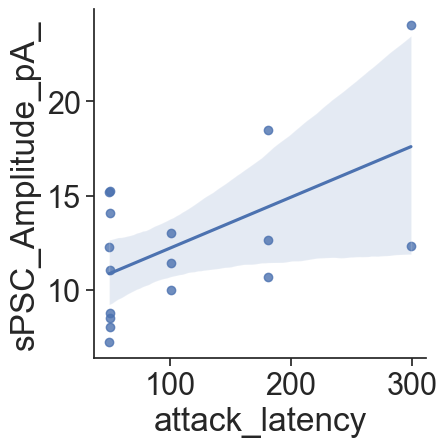

In [11]:
# ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != "contact_latency":  # Skip the contact_latency column
        formula = "attack_latency ~ " + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)

            if model.pvalues[y] < 0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x="attack_latency", y=y, data=ephys_behav)
                plt.show()

        except Exception as e:
            continue

In [12]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd', 'agrpkd'], dtype=object)

## All properties

Instant_freq_(Hz)                        sum_sq     df         F   PR(>F)
Q("Ih_at_-120mV")    0.136292    1.0  0.014082  0.90577
Residual           996.871194  103.0       NaN      NaN


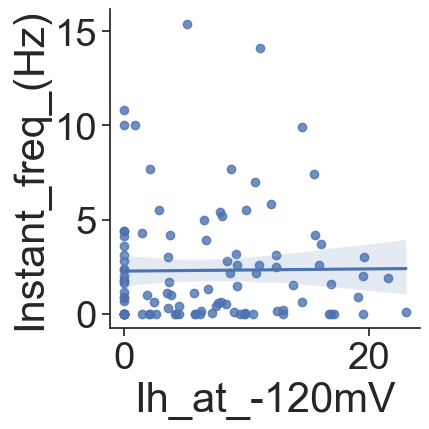

In [47]:
# filter_cat = ["Pre"]

# # set categorical variables
# ephys["Behaviour_6hFD"] = pd.Categorical(
#     ephys["Behaviour_6hFD"], categories=filter_cat, ordered=True
# )

selected = ephys[(~ ephys['experiment_day'].str.contains('2025'))&  (ephys.Behaviour_6hFD == "Pre")]

epnys = ephys[(~ ephys['experiment_day'].str.contains('2025'))]

sns.lmplot(
    x="Ih_at_-120mV",
    y="Instant_freq_(Hz)",
    data=selected,
    height=5,
    aspect=1,
)

variable = "Instant_freq_(Hz)"
x_variable = "Ih_at_-120mV"
formula = f'Q("{variable}") ~ Q("{x_variable}")'
model = smf.ols(formula, data=selected).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(variable, anova_results)


# preprocess_plot(
#     ephys[ephys.Behaviour_6hFD.isin(filter_cat)],
#     "Behaviour_6hFD",
#     "pan",
#     palette=["Gray", "Tab:red", "Tab:Blue", "Gray", "Tab:red", "Tab:red", "Gray"],
#     order=filter_cat,
#     plotting=True,
# )

## Individual plots - panMPOA

In [276]:
# subset df for those groups needed for firing freq. plot
ephys = pd.read_csv("sampled_ephys_data.csv")
ephys2 = ephys.loc[
    (~ ephys['experiment_day'].str.contains('2025'))&
    (ephys["Behaviour_6hFD"] == "Pre")
    | (ephys["Behaviour_6hFD"] == "Agg-")
    | (ephys["Behaviour_6hFD"] == "Agg+")
]

In [72]:
ls

['Cm(pF)',
 'Firing_freq_(Hz)_I0',
 'Instant_freq_(Hz)',
 'isi_(ms)',
 'CaT',
 'Ih_at_-120mV',
 'AP_ampl',
 'AP_halfwidth',
 'AP_time_to_peak',
 'area(mV_ms)',
 'rheobase_at_-60mV_(pA)',
 'AHP_(mV)',
 'Vm',
 'Input_Resistance',
 'sPSC_frequency',
 'sPSC_Amplitude(pA)',
 'sPSCs_Rise time',
 'sPSCs (decay)']

In [73]:
for column in ['Vm'] :
    print(column)
    selected = ephys2.copy()
    print(selected.dropna(subset=[column]).groupby("Behaviour_6hFD")['experiment_day'].nunique())
    print(selected.dropna(subset=[column]).groupby("Behaviour_6hFD")['ID_mouse'].nunique())

Vm
Behaviour_6hFD
Agg+     20
Agg-     22
Pre     125
Name: experiment_day, dtype: int64
Behaviour_6hFD
Agg+     6
Agg-     3
Pre     24
Name: ID_mouse, dtype: int64


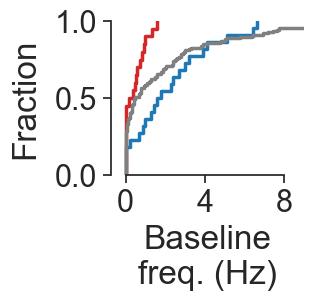

In [74]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys2,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=triple_ff,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [75]:
# mouse and cell numbers
filtered = ephys2.dropna(subset=["Firing_freq_(Hz)_I0"])
mouse_counts = filtered.groupby("Behaviour_6hFD")["ID_mouse"].nunique()
print(f"\033[1mMouse numbers:\033[0m\n \n{mouse_counts}")
cell_counts = ephys2.groupby("Behaviour_6hFD")["Firing_freq_(Hz)_I0"].count()
print(f"\n\033[1mCell counts:\033[0m\n \n{cell_counts}")

Mouse numbers:
 
Behaviour_6hFD
Agg+     6
Agg-     3
Pre     24
Name: ID_mouse, dtype: int64

Cell counts:
 
Behaviour_6hFD
Agg+     20
Agg-     22
Pre     126
Name: Firing_freq_(Hz)_I0, dtype: int64


In [76]:
# Stats
ephys2_pre = ephys2.loc[
    ephys2["Behaviour_6hFD"] == "Pre", "Firing_freq_(Hz)_I0"
].dropna()
ephys2_agg = ephys2.loc[
    ephys2["Behaviour_6hFD"] == "Agg+", "Firing_freq_(Hz)_I0"
].dropna()
ephys2_noagg = ephys2.loc[
    ephys2["Behaviour_6hFD"] == "Agg-", "Firing_freq_(Hz)_I0"
].dropna()

from scipy.stats import mannwhitneyu

# Pre vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)
# Pre vs Agg-
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_noagg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg-:", p_value)
# Agg- vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_noagg, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Agg- vs Agg+:", p_value)

Mann-Whitney U Statistic: 1635.5
P-value Pre vs Agg+: 0.030749462522794993
Mann-Whitney U Statistic: 1087.0
P-value Pre vs Agg-: 0.10485011798307142
Mann-Whitney U Statistic: 352.5
P-value Agg- vs Agg+: 0.0007392103156646884


In [77]:
# stats - one-way ANOVA
from scipy.stats import f_oneway

filtered_groups = ["Pre", "Agg+", "Agg-"]
ephys_filtered = ephys2[ephys2["Behaviour_6hFD"].isin(filtered_groups)]
ephys_filtered = ephys_filtered.dropna(subset=["Behaviour_6hFD", "Firing_freq_(Hz)_I0"])
groups = ephys_filtered.groupby("Behaviour_6hFD")["Firing_freq_(Hz)_I0"].apply(
    lambda x: x.dropna().tolist()
)
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result)

# Tukey HSD
tukey_results = pairwise_tukeyhsd(
    ephys_filtered["Firing_freq_(Hz)_I0"], ephys_filtered["Behaviour_6hFD"]
)
print(tukey_results)

One-way ANOVA p-value: F_onewayResult(statistic=3.087235729665219, pvalue=0.04827344179342563)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.7918 0.0718 -0.1223 3.7058  False
  Agg+    Pre   1.4651 0.0553 -0.0261 2.9563  False
  Agg-    Pre  -0.3266 0.8519 -1.7581 1.1049  False
---------------------------------------------------


In [78]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[
    (~ ephys['experiment_day'].str.contains('2025'))&
    (ephys["Behaviour_6hFD"] == "Pre")
    | (ephys["Behaviour_6hFD"] == "Agg-")
    | (ephys["Behaviour_6hFD"] == "Agg+")
    | (ephys["Behaviour_6hFD"] == "npy_antag")
    | (ephys["Behaviour_6hFD"] == "npy_KD_dummy")
    | (ephys["Behaviour_6hFD"] == "ZD7288")
]

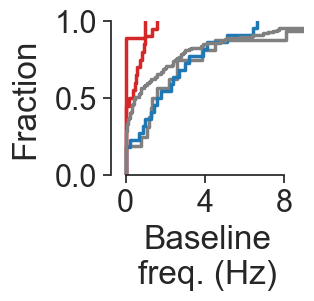

In [79]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys2_all,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=sixtus,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [80]:
# subset df for ZD
ephys2_zd = ephys.loc[
    (~ ephys['experiment_day'].str.contains('2025'))&
    (ephys["Behaviour_6hFD"] == "Pre")
    | (ephys["Behaviour_6hFD"] == "Agg+")
    | (ephys["Behaviour_6hFD"] == "ZD7288")
]

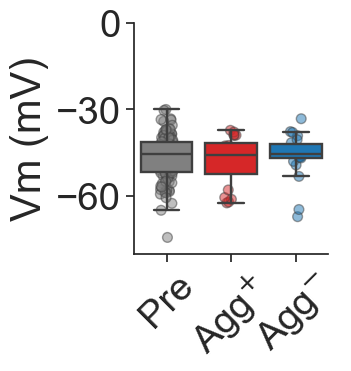

In [81]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [82]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

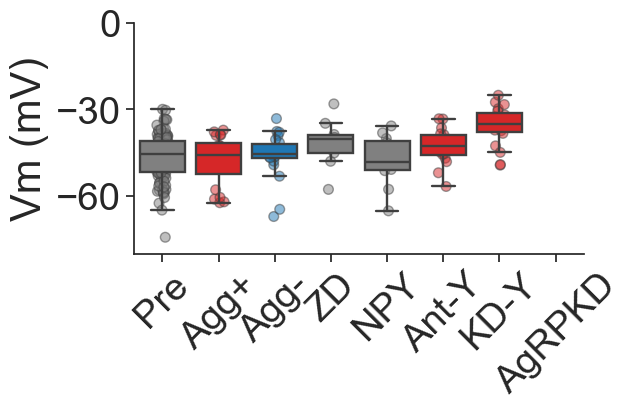

In [83]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(
    ("Pre", "Agg+", "Agg-", "ZD", "NPY", "Ant-Y", "KD-Y", "AgRPKD"), rotation=45
)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [84]:
# ephys.Behaviour_6hFD.unique()

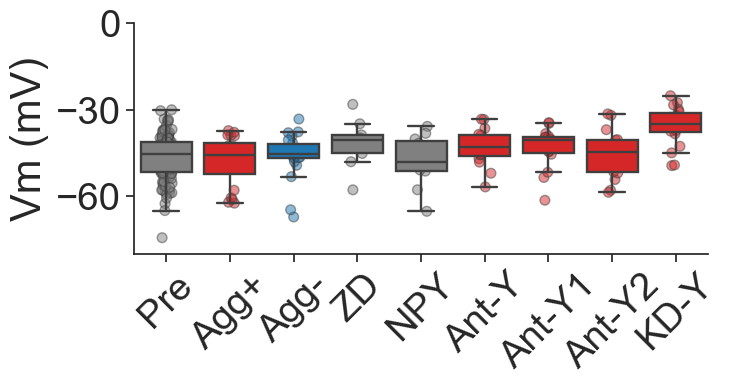

In [85]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS INCL. Y1/Y2 ANT

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=nine,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=nine,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(
    ("Pre", "Agg+", "Agg-", "ZD", "NPY", "Ant-Y", "Ant-Y1", "Ant-Y2", "KD-Y"),
    rotation=45,
)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

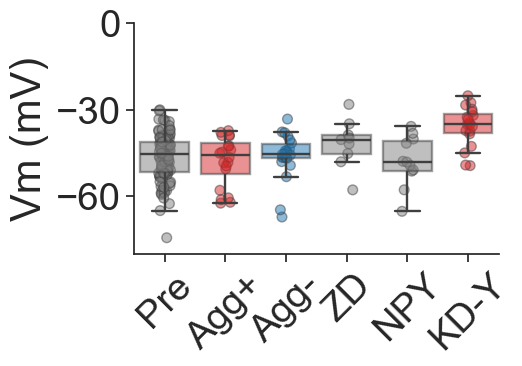

In [86]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS but w/o ANT

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=six,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=six,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "Agg+", "Agg-", "ZD", "NPY", "KD-Y"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

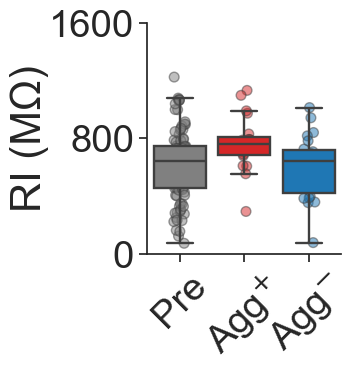

In [87]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [89]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys["Behaviour_6hFD"] == "Pre"]["Input_Resistance"].dropna()
agg_plus_group = ephys[ephys["Behaviour_6hFD"] == "Agg+"]["Input_Resistance"].dropna()
agg_minus_group = ephys[ephys["Behaviour_6hFD"] == "Agg-"]["Input_Resistance"].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result)

all_input_resistances = np.concatenate([pre_group, agg_plus_group, agg_minus_group])
group_labels = (
    ["Pre"] * len(pre_group)
    + ["Agg+"] * len(agg_plus_group)
    + ["Agg-"] * len(agg_minus_group)
)
tukey_results = pairwise_tukeyhsd(all_input_resistances, group_labels)
print(tukey_results)

One-way ANOVA p-value: F_onewayResult(statistic=3.4277724744956113, pvalue=0.035188073792471235)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0669 -330.5335   8.6799  False
  Agg+    Pre -143.0595 0.0354 -278.2742  -7.8449   True
  Agg-    Pre   17.8673 0.9408  -109.326 145.0606  False
--------------------------------------------------------


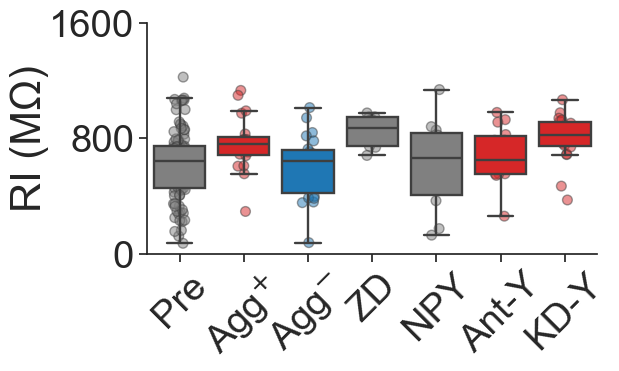

In [90]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "Ant-Y", "KD-Y"), rotation=45
)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

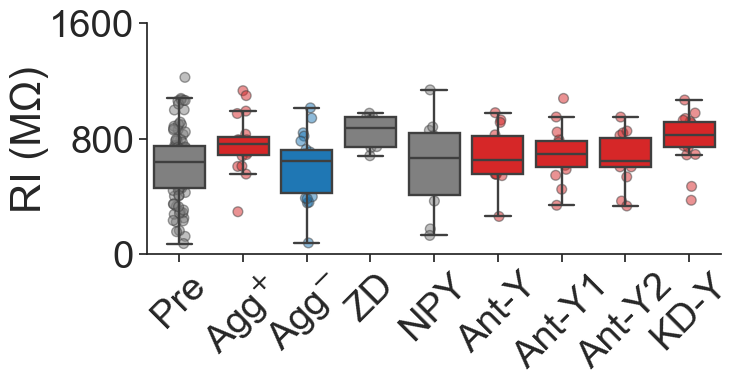

In [91]:
# Input resistance - VERSION WITH ALL GROUPS INCL Y1/2

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=nine,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=nine,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(
    (
        "Pre",
        r"Agg$^{+}$",
        r"Agg$^{-}$",
        "ZD",
        "NPY",
        "Ant-Y",
        "Ant-Y1",
        "Ant-Y2",
        "KD-Y",
    ),
    rotation=45,
)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

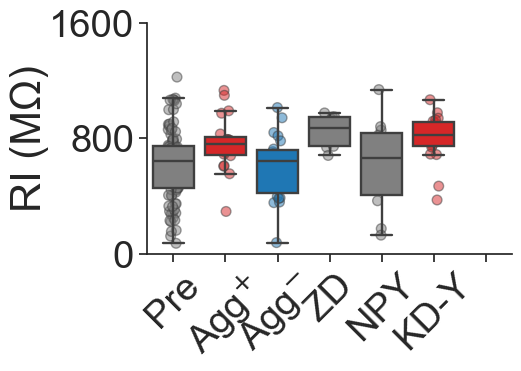

In [92]:
# Input resistance - VERSION WITH ALL GROUPS w/o Ant

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=six,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=six,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "KD-Y"), rotation=45
)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [274]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey;
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby("Behaviour_6hFD")["Input_Resistance"].agg(
    ["count", "var"]
)
# print(group_summary)

# filter for the groups we want
groups_to_include = [
    "Pre",
    "Agg+",
    "Agg-",
]  # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys3 = ephys[ephys["Behaviour_6hFD"].isin(groups_to_include)]

# Ensure 'Input_Resistance' is numeric and 'Behaviour_6hFD' is categorical
ephys3["Input_Resistance"] = pd.to_numeric(ephys3["Input_Resistance"], errors="coerce")
ephys3["Behaviour_6hFD"] = ephys3["Behaviour_6hFD"].astype("category")

# Drop rows with missing values
ephys3 = ephys3.dropna(subset=["Input_Resistance"])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary["count"] > 1) and all(group_summary["var"] > 0):
    anova_result = f_oneway(
        ephys3["Input_Resistance"][ephys3["Behaviour_6hFD"] == "Pre"],
        ephys3["Input_Resistance"][ephys3["Behaviour_6hFD"] == "Agg+"],
        ephys3["Input_Resistance"][ephys3["Behaviour_6hFD"] == "Agg-"],
    )
    
    print(anova_result)
    dof = len(groups_to_include) - 1, len(ephys3) - len(groups_to_include)
    print("Degrees of freedom:", dof)

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(
        ephys3["Input_Resistance"], ephys3["Behaviour_6hFD"]
    )
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")

# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys["Behaviour_6hFD"] == "Pre"]["Input_Resistance"].dropna()
group_zd = ephys[ephys["Behaviour_6hFD"] == "ZD7288"]["Input_Resistance"].dropna()
group_npy = ephys[ephys["Behaviour_6hFD"] == "npy_100"]["Input_Resistance"].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests

p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {u_statistic2, p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {u_statistic3, p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys["Behaviour_6hFD"] == "Agg+"]["Input_Resistance"].dropna()
group_ant = ephys[ephys["Behaviour_6hFD"] == "npy_antag"]["Input_Resistance"].dropna()
group_ant1 = ephys[ephys["Behaviour_6hFD"] == "npy1r_antag"][
    "Input_Resistance"
].dropna()
group_ant2 = ephys[ephys["Behaviour_6hFD"] == "npy2r_antag"][
    "Input_Resistance"
].dropna()
group_kd = ephys[ephys["Behaviour_6hFD"] == "npykd"]["Input_Resistance"].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {u_statistic7, p_value7}")
print("Corrected p-values:", p_adjusted)

F_onewayResult(statistic=3.4277724744956113, pvalue=0.035188073792471235)
Degrees of freedom: (2, 141)
One-way ANOVA p-value: 0.035188073792471235
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0669 -330.5335   8.6799  False
  Agg+    Pre -143.0595 0.0354 -278.2742  -7.8449   True
  Agg-    Pre   17.8673 0.9408  -109.326 145.0606  False
--------------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': (165.0, 0.0014250033930616958)
Mann-Whitney U test between 'Pre' and 'NPY': (568.0, 0.9923429736237652)
Corrected p-values: [0.00285001 0.99234297]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.17194793289971422
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.25238104262144023
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.14011244626592897
Mann-Whitney U test between 'Agg+' and 'KD-Y': (14

In [273]:

group_summary = ephys.groupby("Behaviour_6hFD")["Vm"].agg(
    ["count", "var"]
)
# print(group_summary)

# filter for the groups we want
groups_to_include = [
    "Pre",
    "Agg+",
    "Agg-",
]  # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys3 = ephys[ephys["Behaviour_6hFD"].isin(groups_to_include)]

# Ensure 'Input_Resistance' is numeric and 'Behaviour_6hFD' is categorical
ephys3["Vm"] = pd.to_numeric(ephys3["Vm"], errors="coerce")
ephys3["Behaviour_6hFD"] = ephys3["Behaviour_6hFD"].astype("category")

# Drop rows with missing values
ephys3 = ephys3.dropna(subset=["Vm"])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary["count"] > 1) and all(group_summary["var"] > 0):
    anova_result = f_oneway(
        ephys3["Vm"][ephys3["Behaviour_6hFD"] == "Pre"],
        ephys3["Vm"][ephys3["Behaviour_6hFD"] == "Agg+"],
        ephys3["Vm"][ephys3["Behaviour_6hFD"] == "Agg-"],
    )
    
    print(anova_result)
    dof = len(groups_to_include) - 1, len(ephys3) - len(groups_to_include)
    print("Degrees of freedom:", dof)

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(
        ephys3["Vm"], ephys3["Behaviour_6hFD"]
    )
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")

# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys["Behaviour_6hFD"] == "Pre"]["Vm"].dropna()
group_zd = ephys[ephys["Behaviour_6hFD"] == "ZD7288"]["Vm"].dropna()
group_npy = ephys[ephys["Behaviour_6hFD"] == "npy_100"]["Vm"].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests

p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {u_statistic2, p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {u_statistic3, p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys["Behaviour_6hFD"] == "Agg+"]["Vm"].dropna()
group_ant = ephys[ephys["Behaviour_6hFD"] == "npy_antag"]["Vm"].dropna()
group_ant1 = ephys[ephys["Behaviour_6hFD"] == "npy1r_antag"][
    "Vm"
].dropna()
group_ant2 = ephys[ephys["Behaviour_6hFD"] == "npy2r_antag"][
    "Vm"
].dropna()
group_kd = ephys[ephys["Behaviour_6hFD"] == "npykd"]["Vm"].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {u_statistic7, p_value7}")
print("Corrected p-values:", p_adjusted)

F_onewayResult(statistic=0.36970571297249527, pvalue=0.6915119955699536)
Degrees of freedom: (2, 164)
One-way ANOVA p-value: 0.6915119955699536
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.8983 0.7063 -3.7458 7.5425  False
  Agg+    Pre   1.4441 0.7181 -2.9555 5.8437  False
  Agg-    Pre  -0.4542  0.965 -4.6779 3.7695  False
---------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': (362.0, 0.0754403596268005)
Mann-Whitney U test between 'Pre' and 'NPY': (732.0, 0.7254521655700295)
Corrected p-values: [0.15088072 0.72545217]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.10110085963698442
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.14705851921929672
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.4735797982690084
Mann-Whitney U test between 'Agg+' and 'KD-Y': (46.0, 5.530373549353605e-05)
Corrected p-val

In [94]:
# cell numbers
group_counts = ephys["Behaviour_6hFD"].value_counts()
# print(group_counts)
# mice per group
unique_id_counts = ephys.groupby("Behaviour_6hFD")["ID_mouse"].nunique()
# print(unique_id_counts)

In [95]:
ephys.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)',
       'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'estrous_confirmation'],
      dtype='object')

In [96]:
for variable in ls:

    subset_df = ephys[ephys["Behaviour_6hFD"].isin(["Agg+", "npykd"])]
    print(variable)
    try:
        print(
            stats.mannwhitneyu(
                subset_df[subset_df["Behaviour_6hFD"] == "Agg+"][variable].dropna(),
                subset_df[subset_df["Behaviour_6hFD"] == "npykd"][variable].dropna(),
            )
        )
    except Exception as e:
        print(f"Error processing {variable}: {e}")
        continue

Cm(pF)
Error processing Cm(pF): `x` and `y` must be of nonzero size.
Firing_freq_(Hz)_I0
MannwhitneyuResult(statistic=112.5, pvalue=0.026735672074107823)
Instant_freq_(Hz)
MannwhitneyuResult(statistic=115.5, pvalue=0.03308260548978594)
isi_(ms)
MannwhitneyuResult(statistic=195.5, pvalue=0.8856276130821868)
CaT
MannwhitneyuResult(statistic=185.0, pvalue=0.880181579041291)
Ih_at_-120mV
MannwhitneyuResult(statistic=103.0, pvalue=0.023913065919995057)
AP_ampl
MannwhitneyuResult(statistic=189.5, pvalue=1.0)
AP_halfwidth
MannwhitneyuResult(statistic=151.0, pvalue=0.26802639965384134)
AP_time_to_peak
MannwhitneyuResult(statistic=130.5, pvalue=0.08960591120417029)
area(mV_ms)
MannwhitneyuResult(statistic=170.5, pvalue=0.5846617026404489)
rheobase_at_-60mV_(pA)
MannwhitneyuResult(statistic=168.5, pvalue=0.9513460710428313)
AHP_(mV)
MannwhitneyuResult(statistic=153.5, pvalue=0.3003441399223119)
Vm
MannwhitneyuResult(statistic=46.0, pvalue=5.530373549353605e-05)
Input_Resistance
MannwhitneyuResul

In [97]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

In [137]:
for variable in ls:
    variable = variable
    formula = f'Q("{variable}") ~ C(estrous_stage)'
    subset_df = ephys[ephys["Behaviour_6hFD"].isin(["Pre"])]
    subset_df[variable] = pd.to_numeric(subset_df[variable], errors="coerce")
    subset_df = subset_df[subset_df['estrous_stage'].isin(['P', 'E', 'M', 'D'])].dropna(subset=[variable, 'estrous_stage'])
    model = smf.ols(formula, data=subset_df).fit()
    anova_results = sm.stats.anova_lm(model, typ=2)

    print(variable, anova_results)
    # post hoc test if anova is significant
    if anova_results["PR(>F)"][0] < 0.05:
        tukey = pairwise_tukeyhsd(
            subset_df[variable], subset_df["estrous_stage"], alpha=0.05
        )
        print(tukey)
        # print tukey degrees of freedom
        print("Degrees of freedom:", tukey.df_total)

Cm(pF)                        sum_sq    df         F    PR(>F)
C(estrous_stage)   259.388758   3.0  0.719988  0.554519
Residual          1921.431205  16.0       NaN       NaN
Firing_freq_(Hz)_I0                       sum_sq    df         F    PR(>F)
C(estrous_stage)    6.768693   3.0  0.233363  0.872928
Residual          918.492848  95.0       NaN       NaN
Instant_freq_(Hz)                       sum_sq    df         F   PR(>F)
C(estrous_stage)    4.830318   3.0  0.156837  0.92504
Residual          975.279737  95.0       NaN      NaN
isi_(ms)                         sum_sq    df        F    PR(>F)
C(estrous_stage)  1.325649e+08   3.0  1.02579  0.384881
Residual          4.049268e+09  94.0      NaN       NaN
CaT                        sum_sq    df         F    PR(>F)
C(estrous_stage)   422.826220   3.0  1.669542  0.179853
Residual          7006.825547  83.0       NaN       NaN
Ih_at_-120mV                        sum_sq    df         F    PR(>F)
C(estrous_stage)   467.962991   3.0  4.612

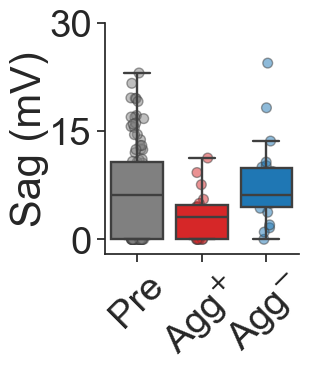

In [99]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

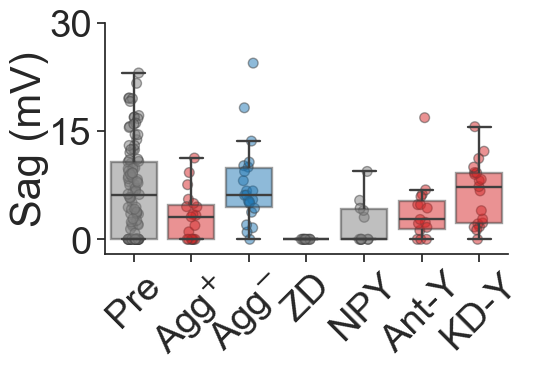

In [100]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
    boxprops={"alpha": 0.5},
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "Ant-Y", "KD-Y", "AgRPKD"),
    rotation=45,
)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

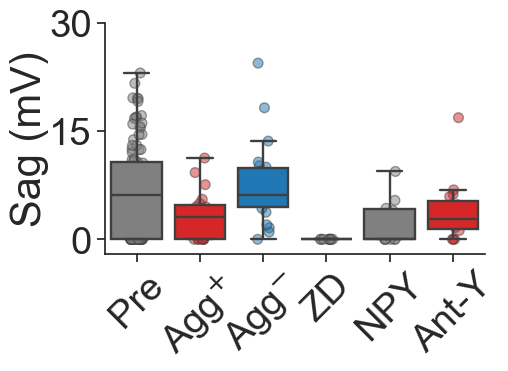

In [101]:
# Ih - VERSION without KD-Y
sns.set(rc={"figure.figsize": (4.9, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "Ant-Y"), rotation=45
)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

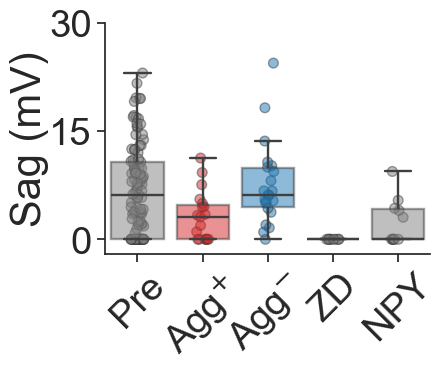

In [102]:
# Ih - VERSION without KD-Y and Ant-Y
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=six,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=six,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

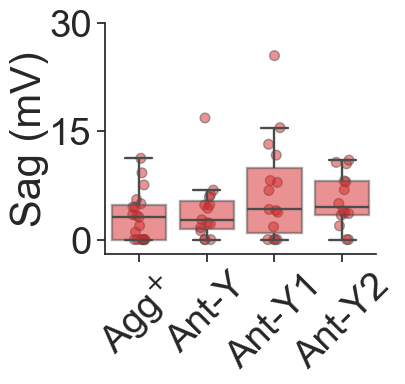

In [103]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels((r"Agg$^{+}$", "Ant-Y", "Ant-Y1", "Ant-Y2"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

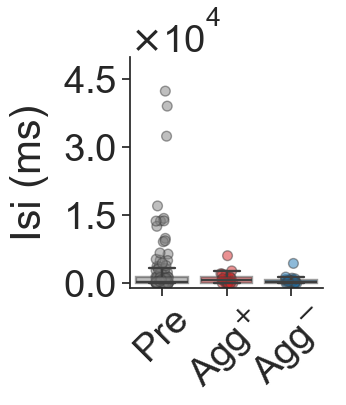

In [104]:
# Isi
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="isi_(ms)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="isi_(ms)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Isi (ms)", labelpad=10)

# Set the y-axis to be in scientific notation
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# Use scientific notation for ticks
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(-1000, 50000)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/isi.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

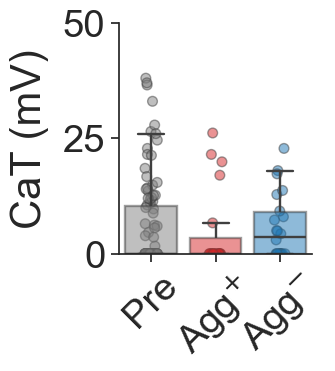

In [105]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="CaT",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="CaT",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("CaT (mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [106]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys["Behaviour_6hFD"] == "Pre"]["CaT"].dropna()
agg_plus_group = ephys[ephys["Behaviour_6hFD"] == "Agg+"]["CaT"].dropna()
agg_minus_group = ephys[ephys["Behaviour_6hFD"] == "Agg-"]["CaT"].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.9206142154386439


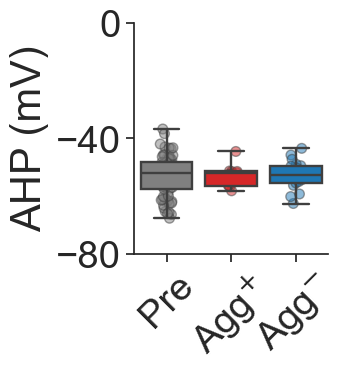

In [107]:
# AHP

ephys_filtered = ephys[ephys["AHP_(mV)"] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=ephys_filtered,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=ephys_filtered,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("AHP (mV)", labelpad=5)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

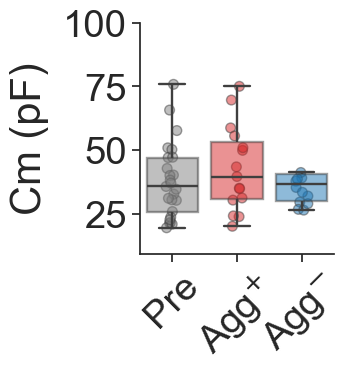

In [108]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Cm(pF)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Cm(pF)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("Cm (pF)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

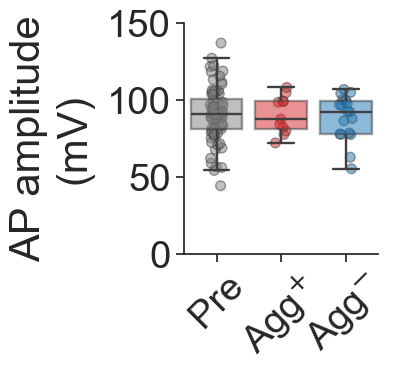

In [109]:
# AP_ampl
ephys_filt = ephys[ephys["AP_ampl"] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AP_ampl",
    data=ephys_filt,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AP_ampl",
    data=ephys_filt,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP amplitude\n(mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(0, 150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

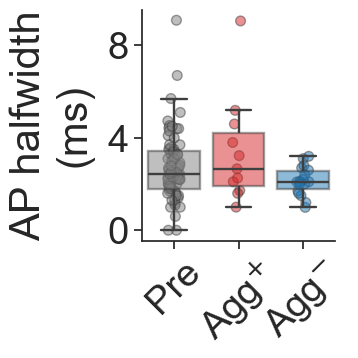

In [110]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")
non_silent = ephys[(~ ephys['experiment_day'].str.contains('2025'))&(ephys.I_zero != "silent")]

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AP_halfwidth",
    data=non_silent,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AP_halfwidth",
    data=non_silent,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP halfwidth\n(ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [111]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys["Behaviour_6hFD"] == "Pre"]["AP_halfwidth"].dropna()
agg_plus_group = ephys[ephys["Behaviour_6hFD"] == "Agg+"]["AP_halfwidth"].dropna()
agg_minus_group = ephys[ephys["Behaviour_6hFD"] == "Agg-"]["AP_halfwidth"].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.9091492239765807


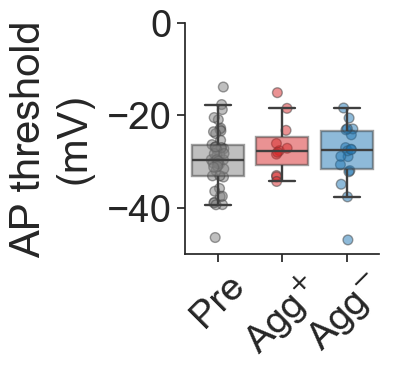

In [113]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/AP threshold/APthreshold_v1.csv"
)

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="state",
    y="AP_threshold_mV",
    data=ap_thresh,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="state",
    y="AP_threshold_mV",
    data=ap_thresh,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP threshold\n(mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [114]:
response_var = "state"
formula = f'AP_threshold_mV ~ Q("{response_var}")'
model = smf.ols(formula, data=ap_thresh).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

                 sum_sq    df         F    PR(>F)
Q("state")    60.676972   2.0  0.722006  0.489308
Residual    2983.398255  71.0       NaN       NaN


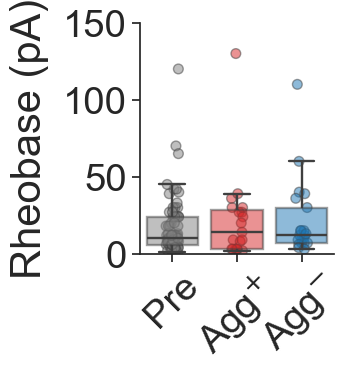

In [115]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="rheobase_at_-60mV_(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="rheobase_at_-60mV_(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("Rheobase (pA)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

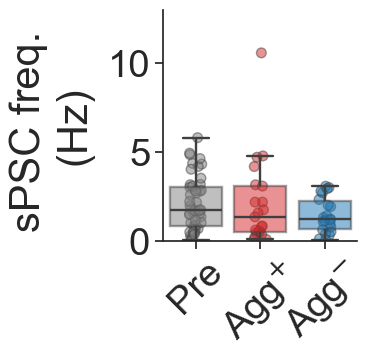

In [116]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_frequency",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_frequency",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC freq. \n(Hz)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 13)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

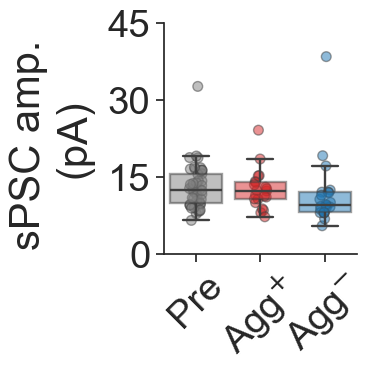

In [117]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC amp. \n(pA)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

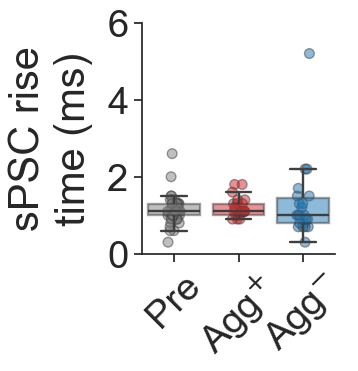

In [118]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSCs_Rise time",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSCs_Rise time",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC rise\ntime (ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

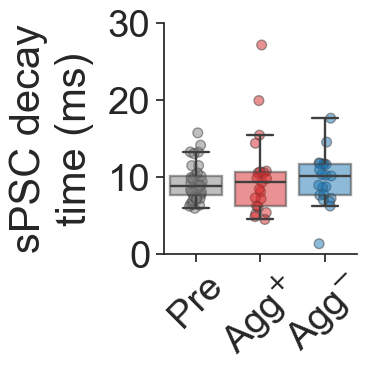

In [119]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")


ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSCs (decay)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSCs (decay)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC decay\ntime (ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

## ZD effect

In [56]:
# gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# gals = pd.concat([gal,no_gal], axis = 0)
# len(no_gal)

In [57]:
# count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
# print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

In [58]:
# preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))],
#                 'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [127]:
trial.shape

(128, 37)

In [134]:
# correlation between input resistance and Sag
trial = ephys[ephys.Behaviour_6hFD.isin(["Pre"])]
trial = trial.rename(
    columns={
        "Ih_at_-120mV": "ih_current",
        "Firing_freq_(Hz)_I0": "firing_freq",
        "sPSC_Amplitude(pA)": "sPSC_Amplitude",
    }
)

model = smf.ols("Input_Resistance ~  ih_current  ", data=trial).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Input_Resistance   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     5.736
Date:                Sun, 07 Sep 2025   Prob (F-statistic):             0.0185
Time:                        23:20:12   Log-Likelihood:                -697.57
No. Observations:                 102   AIC:                             1399.
Df Residuals:                     100   BIC:                             1404.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    686.1192     33.423     20.528      0.000     619.809     752.430
ih_current    -8.7703      3.662     -2.395      0.018     -16.035      -1.505
==============================================================================
Omnibus:                        0.266   Durbin-Watson:                   1.471
Prob(Omnibus):                  0.876   Jarque-Bera (JB):                0.048
Skew:                           0.035   Prob(JB):                        0.976
Kurtosis:                       3.081   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [121]:
trial.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)',
       'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV', 'firing_freq',
       'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ', 'CaT', 'Ih', 'ih_current',
       'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak', 'area(mV_ms)',
       'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm', 'Input_Resistance',
       'sPSC_frequency', 'sPSC_Amplitude', 'sPSCs_Rise time', 'sPSCs (decay)',
       'AC-I0', 'AC_-60', 'Comments', 'estrous_confirmation'],
      dtype='object')

In [122]:
# Correlation between Sag and firing freq

model = smf.ols("firing_freq ~  ih_current  ", data=trial).fit()
# model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,0.014831,1.0,0.001607,0.968099
Residual,931.908744,101.0,NaN,NaN


In [123]:
print("Coefficient of determination (R^2):", model.rsquared)

Coefficient of determination (R^2): 1.5914304800190848e-05


In [124]:
# sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
# plt.xlabel('Ih current (pA)')
# plt.ylabel('Input resistance (MΩ)')
# plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')

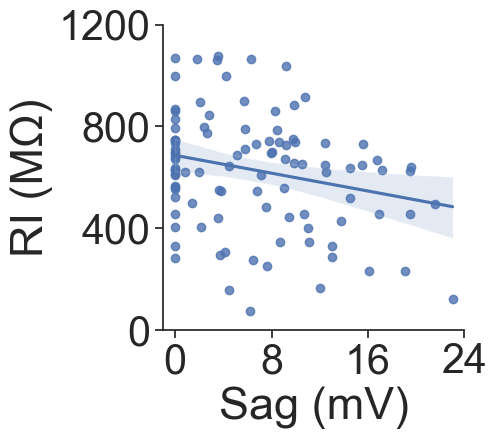

In [128]:
sns.set(font_scale=2.7)
sns.set_style("ticks")
sns.lmplot(
    x="ih_current",
    y="Input_Resistance",
    data=trial,
    palette=["darkgray", "#F97306", "blue"],
    aspect=1.1,
)
plt.ylabel("RI (MΩ)")
plt.xlabel("Sag (mV)")
plt.ylim(0, 1200)
plt.yticks([0, 400, 800, 1200])
plt.xticks([0, 8, 16, 24])
plt.xlim(-1, 24)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ih_input_resistance.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [65]:
prop = "sPSC_frequency"
# conduct U test
group_pre = ephys[ephys["Behaviour_6hFD"] == "Pre"][prop].dropna()
group_ZD = ephys[ephys["Behaviour_6hFD"] == "ZD7288"][prop].dropna()

# import Mann-Whitney U test
from scipy.stats import mannwhitneyu

u_statistic, p_value = mannwhitneyu(group_pre, group_ZD)
print(p_value)

6.656721418097667e-05


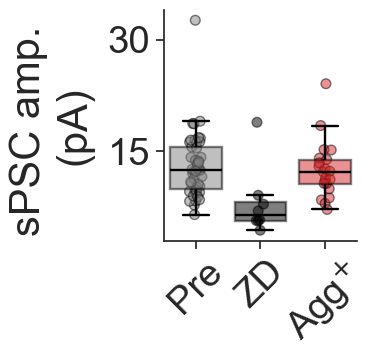

In [66]:
# l = 'Instant_freq_(Hz)'
# max = ephys[l].max()
# cs = ['darkgray', '#F97306', 'Tab:blue']
# conds = ['Pre', 'Agg+', 'Agg-']
# fig, ax = plt.subplots(figsize=(2, 2))
# sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
# sns.despine()
# plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(style="ticks", font_scale=2.5)
prop = "sPSC_Amplitude(pA)"

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y=prop,
    data=ephys,
    order=["Pre", "ZD7288", "Agg+"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["gray", "black", "Tab:red"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y=prop,
    data=ephys,
    order=["Pre", "ZD7288", "Agg+"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=["gray", "black", "Tab:red"],
)
ax.set_xlabel("")
ax.set_ylabel("sPSC amp. \n(pA)", labelpad=10)

ax.set_xticklabels(("Pre", "ZD", r"Agg$^{+}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0,30)
sns.despine(bottom=False, trim=False)
plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/{prop}_ZD.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


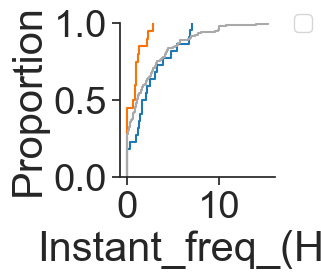

In [67]:
l = "Instant_freq_(Hz)"
max = ephys[l].max()
cs = ["darkgray", "#F97306", "Tab:blue"]
conds = ["Pre", "Agg+", "Agg-"]
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(
    data=ephys[ephys.Behaviour_6hFD.isin(conds)],
    x=l,
    hue="Behaviour_6hFD",
    palette=cs,
    ax=ax,
)
sns.despine()
plt.legend(loc="center left", bbox_to_anchor=(1.05, 1), fontsize=16)

# plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

## Individual plots Gal+ vs Gal-

In [68]:
gals = df[(df.Gal_positive.isin(["yes", "no"])) & (df.Behaviour_6hFD != "Pre")]

In [69]:
print(
    f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice"
)

Number of Gal+ neurons: 9 from 3 mice
Number of Gal- neurons: 10 from 4 mice


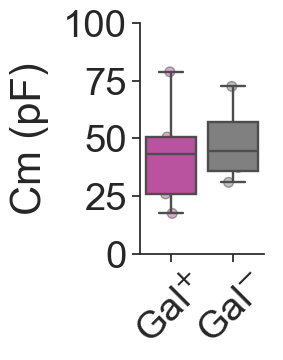

In [70]:
# Cm Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Cm(pF)",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Cm(pF)",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Cm (pF)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.7))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

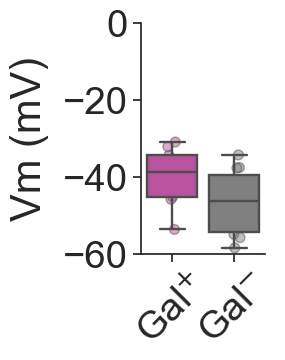

In [71]:
# Vm Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Vm",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Vm",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.7))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [72]:
# stats - U test
gal_positive_data = gals[gals["Gal_positive"] == "yes"]["Vm"]
gal_negative_data = gals[gals["Gal_positive"] == "no"]["Vm"]
u_statistic, p_value = mannwhitneyu(gal_positive_data, gal_negative_data)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.11134688653314041


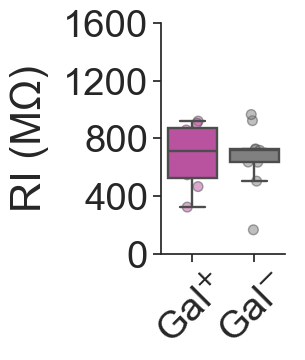

In [73]:
# RI Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Input_Resistance",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Input_Resistance",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.7))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

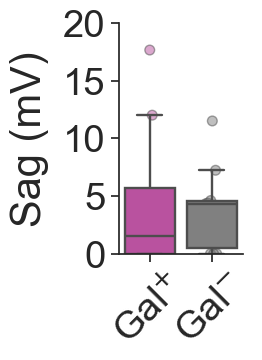

In [74]:
# Ih Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Ih_at_-120mV",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Ih_at_-120mV",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.7))

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [75]:
# stats - U test
gal_positive_sag = gals[gals["Gal_positive"] == "yes"]["Input_Resistance"].dropna()
gal_negative_sag = gals[gals["Gal_positive"] == "no"]["Input_Resistance"].dropna()
u_statistic, p_value = mannwhitneyu(gal_positive_sag, gal_negative_sag)
print("Mann-Whitney U test p-value:", u_statistic, p_value)

Mann-Whitney U test p-value: 36.0 1.0


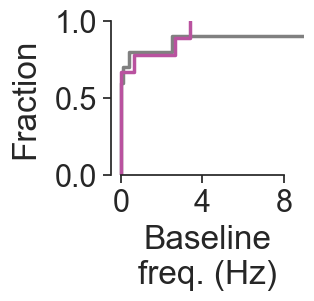

In [76]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=gals,
    x="Firing_freq_(Hz)_I0",
    hue="Gal_positive",
    palette=dual,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

## Silent proportion

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      6       9      5   20
Agg-                      4       4     14   22
Pre                      22      34     70  126
ZD7288                    0       8      1    9
agrpkd                    7      14     22   43
npy1r_antag               2       3     10   15
npy2r_antag               3       6      6   15
npy_100                   2       7      2   11
npy_antag                 4       3      9   16
npykd                     3       5     11   19
All                      53      93    150  296
32.66963060758784 0.01829367480679601 18


Text(0.5, 1.0, 'silent_prop')

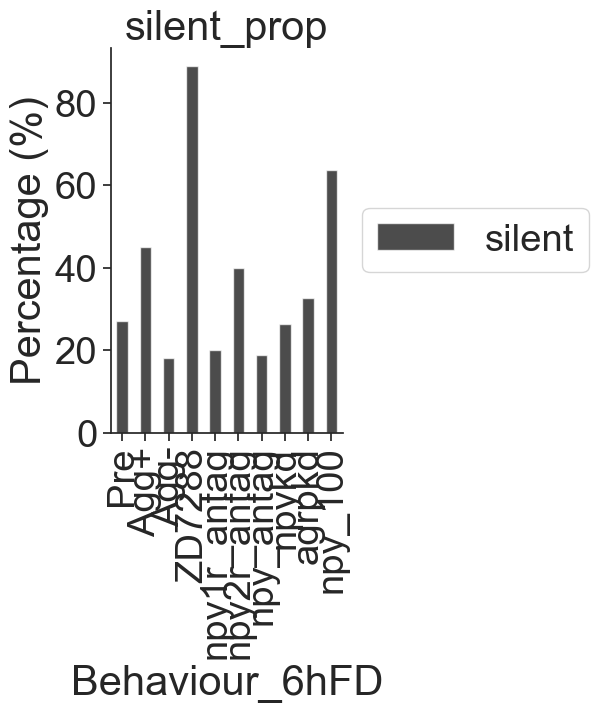

In [277]:
## silent proportion
cols = ["silent"]
cat = [
    "Pre",
    "Agg+",
    "Agg-",
    "ZD7288",
    "npy1r_antag",
    "npy2r_antag",
    "npy_antag",
    "npykd",
    "agrpkd",
    "npy_100",
]
filtered_ephys = ephys[ephys.ID_mouse != "JKAJ37.6g"]

silent_prop = proportion(
    filtered_ephys[(filtered_ephys.Behaviour_6hFD.isin(cat))],
    "Behaviour_6hFD",
    "I_zero_reclassified",
    cols,
)
silent_prop["Behaviour_6hFD"] = pd.Categorical(silent_prop["Behaviour_6hFD"], cat)
silent_prop = silent_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(silent_prop, "Behaviour_6hFD")
plt.xticks(rotation=90)
plt.title("silent_prop")
# plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

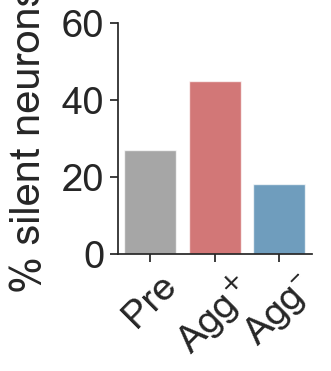

In [281]:
# % silent neurons
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("% silent neurons", labelpad=10)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 60)
sns.despine(bottom=False)
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [282]:
silent_df = silent_prop.loc[:, ["Behaviour_6hFD", "silent"]]

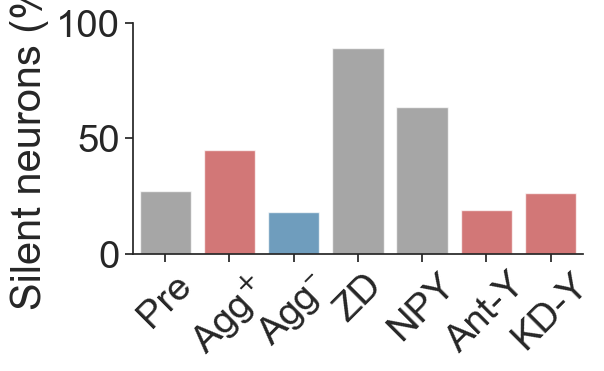

In [283]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    palette=seven,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{–}$", "ZD", "NPY", "Ant-Y", "KD-Y"), rotation=45
)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

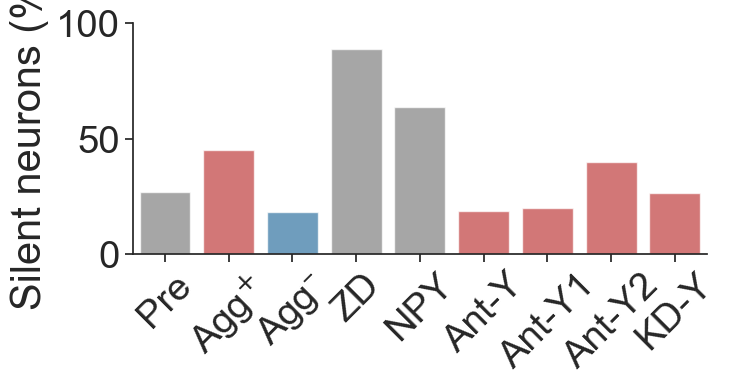

In [284]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    palette=nine,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(
    (
        "Pre",
        r"Agg$^{+}$",
        r"Agg$^{–}$",
        "ZD",
        "NPY",
        "Ant-Y",
        "Ant-Y1",
        "Ant-Y2",
        "KD-Y",
    ),
    rotation=45,
)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

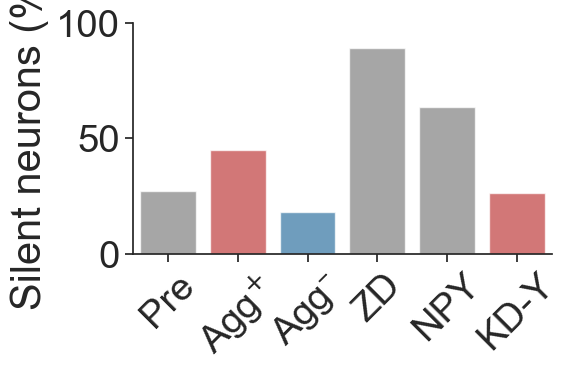

In [285]:
# % silent neurons - VERSION WITH ALL GROUPS but w/o Ant
sns.set(rc={"figure.figsize": (5.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")


g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    palette=six,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$", "ZD", "NPY", "KD-Y"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
#     pad_inches=0.5,
# )

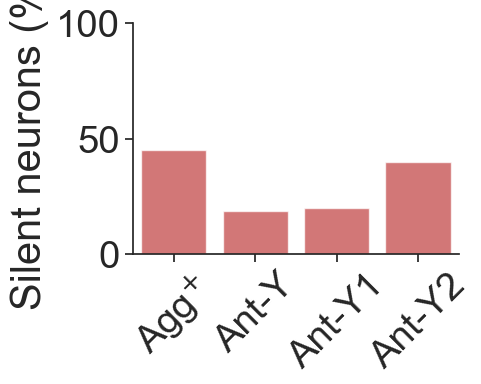

In [286]:
# % silent neurons - VERSION WITH ONLY ANT
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    palette=ant,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels((r"Agg$^{+}$", "Ant-Y", "Ant-Y1", "Ant-Y2"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ant.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
#     pad_inches=0.5,
# )

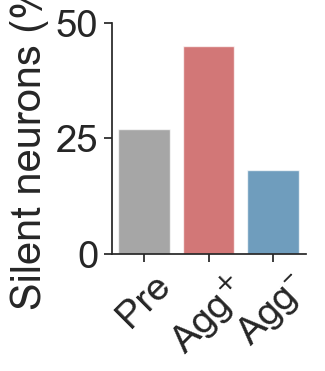

In [287]:
# % silent neurons - only Pre/Agg+/Agg-
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 50)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_short.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

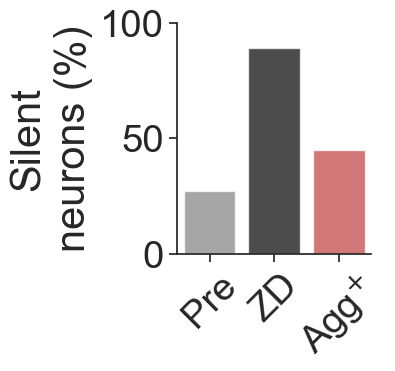

In [288]:
# % silent neurons - Pre/Agg+/ZD
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "ZD7288", "Agg+"],
    palette=["gray", "black", "Tab:red"],
    alpha=0.7,
)
plt.ylabel("Silent\nneurons (%)", labelpad=5)
g.set_xticklabels(("Pre", "ZD", r"Agg$^{+}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ZD.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [290]:
# mouse numbers
filtered = ephys.dropna(subset=["I_zero_reclassified"])
mouse_counts = filtered.groupby("Behaviour_6hFD")["ID_mouse"].nunique()
mouse_counts

Behaviour_6hFD
Agg+               6
Agg-               3
Pre               24
ZD7288             1
ZD7288_20          1
agrp_100           5
agrpkd             7
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     1
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64

In [293]:
# stats
# make contingency table (based on ephys df, not silent_prop, which only has %)
ephys2 = ephys.copy()
ephys2["I_zero_reclassified"] = ephys2["I_zero_reclassified"].replace(
    {"phasic": "active", "tonic": "active"}
)
contingency_table = (
    ephys2.groupby(["Behaviour_6hFD", "I_zero_reclassified"])
    .size()
    .unstack(fill_value=0)
)
contingency_table["active"] = contingency_table.sum(axis=1) - contingency_table.get(
    "silent", 0
)
contingency_table = contingency_table[["silent", "active"]]
print(contingency_table)

# groups = ['Agg+','Agg-','Pre','ZD7288','npy_100','npy_antag','npykd'] #'npy1r_antag','npy2r_antag',

# (1) Pre/Agg+/Agg- ==================================

groups = ["Agg+", "Agg-", "Pre"]
all_stats = []
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]

        # Create contingency table
        table = [
            [
                contingency_table.loc[group1, "silent"],
                contingency_table.loc[group1, "active"],
            ],
            [
                contingency_table.loc[group2, "silent"],
                contingency_table.loc[group2, "active"],
            ],
        ]

        # Perform Fisher's exact test
        stat, p_value = fisher_exact(table)

        # Store the p-value and the comparison
        all_stats.append(stat)
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

# Print the results
for comp, stat, pval, pval_corr in zip(comparisons, all_stats, p_values, pvals_corrected):
    print(
        f"Comparison: {comp}, Stat: {stat}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}"
    )


# (2) Pre/ZD/NPY ==================================

groups = ["Pre", "ZD7288", "npy_100"]
p_values = []
all_stats = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]

        # Create contingency table
        table = [
            [
                contingency_table.loc[group1, "silent"],
                contingency_table.loc[group1, "active"],
            ],
            [
                contingency_table.loc[group2, "silent"],
                contingency_table.loc[group2, "active"],
            ],
        ]

        # Perform Fisher's exact test
        stat, p_value = fisher_exact(table)

        # Store the p-value and the comparison
        all_stats.append(stat)
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

# Print the results
for comp, stat, pval, pval_corr in zip(comparisons, all_stats, p_values, pvals_corrected):
    print(
        f"Comparison: {comp}, Stat: {stat}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}"
    )

# (3) Agg+/Ant-Y/KD-Y ==================================

groups = ["Agg+", "npy_antag", "npykd"]
p_values = []
all_stats = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]

        # Create contingency table
        table = [
            [
                contingency_table.loc[group1, "silent"],
                contingency_table.loc[group1, "active"],
            ],
            [
                contingency_table.loc[group2, "silent"],
                contingency_table.loc[group2, "active"],
            ],
        ]

        # Perform Fisher's exact test
        stat, p_value = fisher_exact(table)

        # Store the p-value and the comparison
        all_stats.append(stat)
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

# Print the results
for comp, stat, pval, pval_corr in zip(comparisons, all_stats, p_values, pvals_corrected):
    print(
        f"Comparison: {comp}, Stat: {stat}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}"
    )

I_zero_reclassified  silent  active
Behaviour_6hFD                     
Agg+                      9      11
Agg-                      4      18
Pre                      34      92
ZD7288                    8       1
ZD7288_20                 5       0
agrp_100                  5      10
agrpkd                   14      33
npy1r_antag               3      12
npy2r_antag               6       9
npy_10                    2       8
npy_100                   7       4
npy_100_paired            4       0
npy_10_paired             5       1
npy_antag                 3      13
npykd                     5      14
Comparison: Agg+ vs Agg-, Stat: 3.6818181818181817, Original p-value: 9.5594e-02, Corrected p-value: 1.7521e-01
Comparison: Agg+ vs Pre, Stat: 2.213903743315508, Original p-value: 1.1681e-01, Corrected p-value: 1.7521e-01
Comparison: Agg- vs Pre, Stat: 0.6013071895424836, Original p-value: 4.4212e-01, Corrected p-value: 4.4212e-01
Comparison: Pre vs ZD7288, Stat: 0.04619565217391304, O

In [89]:
# % silent neurons CHECK WHETHER THESE VALUES ARE CORRECT!

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
# plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       6      4   10
yes                1       6      2    9
All                1      12      6   19
1.6185185185185187 0.44518771279268876 2


Text(0.5, 1.0, 'galanin_silent_prop')

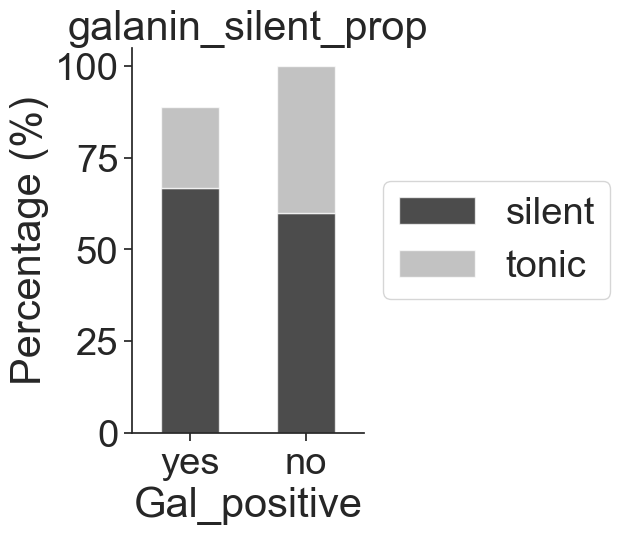

In [90]:
cols = ["silent", "tonic"]
silent_prop = proportion(gals, "Gal_positive", "I_zero", cols)
silent_prop["Gal_positive"] = pd.Categorical(silent_prop["Gal_positive"], ["yes", "no"])
silent_prop = silent_prop.sort_values(by=["Gal_positive"])
prop_plot(silent_prop, "Gal_positive")
plt.title("galanin_silent_prop")
# plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

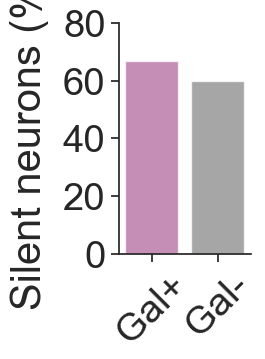

In [91]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Gal_positive",
    y="silent",
    order=["yes", "no"],
    palette=dual,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Gal+", "Gal-"), rotation=45)
plt.xlabel("")
plt.ylim(0, 80)
g.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

## Adaptive prop (DB)

In [92]:
## adaptive proportion
cols = ["yes", "no"]
cat = [
    "Pre",
    "Agg+",
    "Agg-",
    "ZD7288",
    "npy_100",
    "npy_antag",
    "npy1r_antag",
    "npy2r_antag",
    "npykd",
]
ad_prop = proportion(
    ephys[ephys.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "Adaptive", cols
)
# ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
# ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
# ad_prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1   7   12   20
Agg-            0  18    3   21
Pre             1  25   32   58
ZD7288          1   0    8    9
npy1r_antag     0   9    6   15
npy2r_antag     0  10    4   14
npy_100         0   7    2    9
npy_antag       0   5    5   10
npykd           0  10    9   19
All             3  91   81  175
33.24387497490273 0.006859242951356142 16


In [93]:
ad_prop

Adaptive,Behaviour_6hFD,yes,no
0,Agg+,60.000000,35.000000
1,Agg-,14.285714,85.714286
2,Pre,55.172414,43.103448
3,ZD7288,88.888889,0.000000
4,npy1r_antag,40.000000,60.000000
5,npy2r_antag,28.571429,71.428571
6,npy_100,22.222222,77.777778
7,npy_antag,50.000000,50.000000
8,npykd,47.368421,52.631579


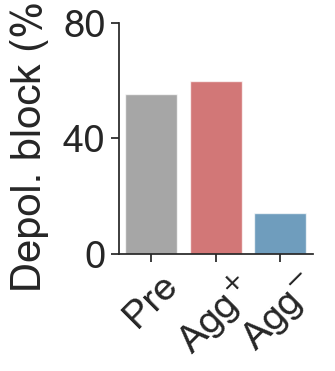

In [94]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    x="Behaviour_6hFD",
    y="yes",
    data=ad_prop,
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)

plt.ylabel("Depol. block (%)", labelpad=10)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

plt.xlabel("")
plt.ylim(top=60)
plt.yticks(np.arange(0, 81, 40))
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             5    3    8
yes            3    5    8
All            8    8   16
0.25 0.6170750774519739 1


Text(0.5, 1.0, 'galanin_adaptive_prop')

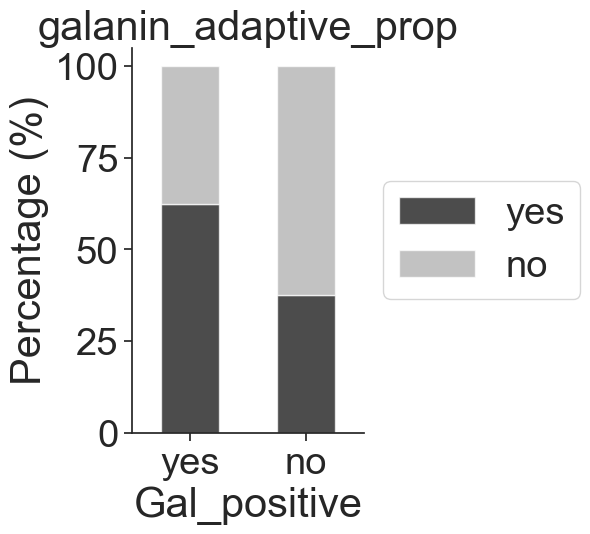

In [95]:
cols = ["yes", "no"]
ad_prop = proportion(gals, "Gal_positive", "Adaptive", cols)
ad_prop["Gal_positive"] = pd.Categorical(ad_prop["Gal_positive"], ["yes", "no"])
ad_prop = ad_prop.sort_values(by=["Gal_positive"])
prop_plot(ad_prop, "Gal_positive")
plt.title("galanin_adaptive_prop")
# plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## Calcium T prop

cat_categ        no  yes  All
Behaviour_6hFD               
Agg+             14    5   19
Agg-             10   12   22
Pre              74   44  118
ZD7288            6    3    9
ZD7288_20         2    1    3
agrp_100         13    2   15
agrpkd           11    8   19
npy1r_antag       9    6   15
npy2r_antag       9    5   14
npy_10            8    2   10
npy_100           6    5   11
npy_antag        14    1   15
npykd            14    5   19
All             190   99  289
15.82435498287984 0.1994140316106438 12


Text(0.5, 1.0, 'CaT_prop')

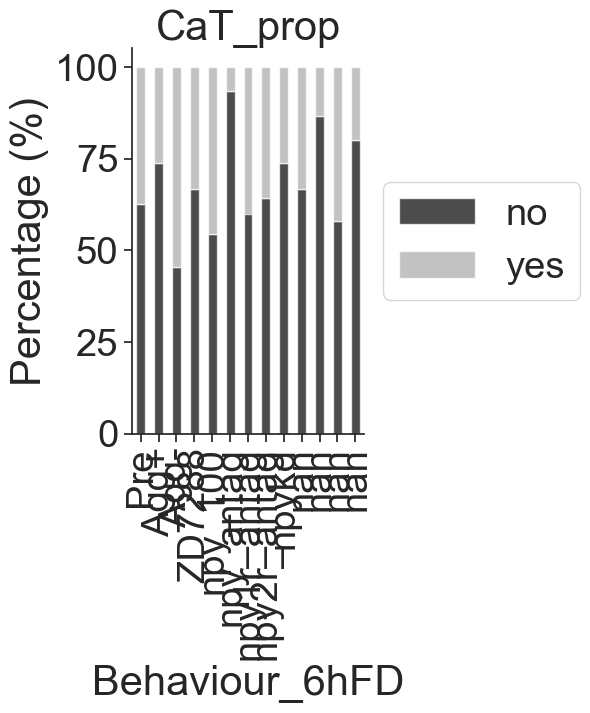

In [96]:
## calcium T proportion
cols = ["no", "yes"]
ca_prop = proportion(ephys, "Behaviour_6hFD", "cat_categ", cols)
ca_prop["Behaviour_6hFD"] = pd.Categorical(ca_prop["Behaviour_6hFD"], cat)
ca_prop = ca_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(ca_prop, "Behaviour_6hFD")
plt.xticks(rotation=90)

plt.title("CaT_prop")
# plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             4    6   10
yes            5    3    8
All            9    9   18
0.225 0.6352562959972483 1


Text(0.5, 1.0, 'galanin_CaT_prop')

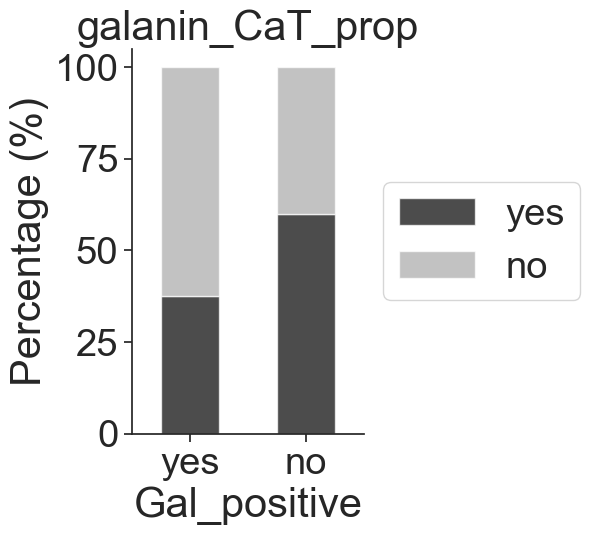

In [97]:
cols = ["yes", "no"]
ca_prop = proportion(gals, "Gal_positive", "cat_categ", cols)
ca_prop["Gal_positive"] = pd.Categorical(ca_prop["Gal_positive"], ["yes", "no"])
ca_prop = ca_prop.sort_values(by=["Gal_positive"])
prop_plot(ca_prop, "Gal_positive")

plt.title("galanin_CaT_prop")
# plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+             7   12   19
Agg-             1   21   22
Pre             32   86  118
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
agrpkd           1   18   19
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             82  215  297
61.17262675035552 7.299267647864261e-08 14


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'Pre'),
  Text(1, 0, 'Agg+'),
  Text(2, 0, 'Agg-'),
  Text(3, 0, 'ZD7288'),
  Text(4, 0, 'npy_100'),
  Text(5, 0, 'npy_antag'),
  Text(6, 0, 'npy1r_antag'),
  Text(7, 0, 'npy2r_antag'),
  Text(8, 0, 'npykd'),
  Text(9, 0, 'nan'),
  Text(10, 0, 'nan'),
  Text(11, 0, 'nan'),
  Text(12, 0, 'nan'),
  Text(13, 0, 'nan'),
  Text(14, 0, 'nan')])

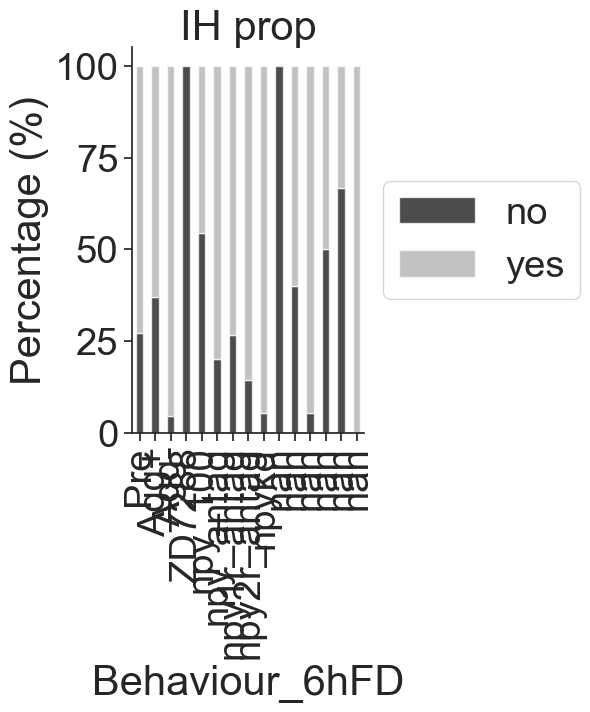

In [98]:
ephys.loc[(ephys["Ih_at_-120mV"] == 0), "IH"] = "no"
ephys.loc[(ephys["Ih_at_-120mV"] > 0), "IH"] = "yes"
cols = ["no", "yes"]

ca_prop = proportion(ephys, "Behaviour_6hFD", "IH", cols)
ca_prop["Behaviour_6hFD"] = pd.Categorical(ca_prop["Behaviour_6hFD"], cat)
ca_prop = ca_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(ca_prop, "Behaviour_6hFD")

plt.title("IH prop")
plt.xticks(rotation=90)
# plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic               10   40   50
silent               38   60   98
tonic                34  115  149
All                  82  215  297
9.272964868642068 0.009691729032010451 2


Text(0.5, 0, '')

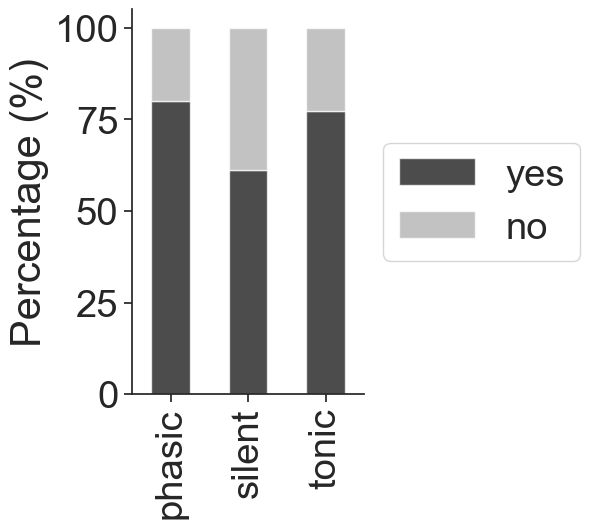

In [99]:
cols = ["yes", "no"]
ih_prop = proportion(ephys, "I_zero_reclassified", "IH", cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, "I_zero_reclassified")
plt.xticks(rotation=90)
plt.xlabel("")

# Ramp analysis (excitability)

In [11]:
from glob import glob

path = "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp"
states = [
    "Pre",
    "Agg+",
    "Agg-",
    "NPY 10nM",
    "NPY 100nM",
    "NPY Antag",
    "NPY1R",
    "NPY2R",
    "NPY-KD",
    "ZD7288",
    "Ramp_Agrp_KD",
]

ramp_path = "ramps_all.csv"
import os

if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)
    ephys = pd.read_csv("sampled_ephys_data.csv")

else:
    # list all directory in filepath
    df_state = pd.DataFrame()

    for state in states:
        files = [file for file in glob(f"{path}/{state}/*.xlsx")]

        df_files = []
        for file in files:
            if file.startswith("~$"):
                continue
            try:
                df_file = pd.read_excel(file)

            except ValueError:
                print(file, state + " failed")
                continue
            df_file = df_file[
                (df_file["Event start "] != 0) & (df_file["Event end "] != 0)
            ]
            df_file["filename"] = file.split("/")[-1]
            df_file = df_file.dropna()

            df_files.append(df_file)

        df = pd.concat(df_files)
        df["state"] = state
        df_state = pd.concat([df_state, df])

    df_state.to_csv("ramps_all.csv", index=False)

    ephys = pd.read_csv("sampled_ephys_data.csv")

In [12]:
import re
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


def process_df_state(df_state, states):
    # Rename the column
    df_state.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

    # Create and order the 'Injected' categorical column
    current_cat = np.arange(25, 175, 10)
    df_state["Injected"] = pd.Categorical(
        df_state["Injected"], current_cat
    ).as_ordered()

    # Sort by 'Injected' and drop NaN values
    df_state.sort_values("Injected", inplace=True)
    df_state = df_state.dropna()

    # Create and order the 'state' categorical column
    df_state["state"] = pd.Categorical(df_state["state"], states).as_ordered()

    # Generate a DataFrame with all unique combinations of 'filename' and 'state'
    unique_combinations = df_state[["filename", "state"]].drop_duplicates()

    # Create a MultiIndex with all combinations of unique_combinations and current_cat
    all_combinations = (
        unique_combinations.assign(dummy=1)
        .merge(pd.DataFrame({"Injected": current_cat, "dummy": 1}), on="dummy")
        .drop("dummy", axis=1)
    )

    # Merge with the original data to ensure all combinations are present
    df_state_full = all_combinations.merge(
        df_state, on=["filename", "Injected", "state"], how="left"
    )
    # Calculate the number of spikes
    num_spike = (
        df_state.groupby(by=["filename", "Injected", "state"])["Event start "]
        .nunique()
        .reset_index(name="num_spike")
    )

    # Merge all combinations with num_spike to ensure all categories are present
    num_spike = all_combinations.merge(
        num_spike, on=["filename", "Injected", "state"], how="left"
    ).fillna({"num_spike": 0})

    # Get the first occurrence in each group and drop duplicates
    df_all = (
        df_state_full.groupby(["filename", "Injected", "state"])
        .first()
        .reset_index()
        .drop_duplicates()
    )

    # Calculate the latency
    latency = (
        df_state.groupby(["filename", "Injected", "state"])["Event start "]
        .min()
        .reset_index(name="latency_event_start")
    )

    # Merge the calculated values into df_all
    df_all = pd.merge(df_all, num_spike, on=["filename", "Injected", "state"])
    df_all = pd.merge(df_all, latency, on=["filename", "Injected", "state"])
    df_all["latency"] = df_all["latency_event_start"] - df_all["Ramp_start"]

    return df_all


def test_interaction_pvalues(
    sampled_df, prop, combos, state_col="state", group_var="filename", correction=True
):
    p_values = pd.DataFrame(columns=["comparison", "interaction", "pvalue"])

    for combo in combos:
        sub_df = sampled_df[sampled_df[state_col].isin(combo)].dropna(subset = 'filename')
        sub_df[state_col] = sub_df[state_col].astype("object")

        model = smf.mixedlm(
            f"{prop} ~ Injected * {state_col}",
            sub_df,
            groups=sub_df[group_var],
        ).fit()

        # Find all interaction terms containing both 'Injected' and 'state'
        interaction_terms = [
            term
            for term in model.pvalues.index
            if "Injected" in term and state_col in term
        ]

        for interaction_term in interaction_terms:
            pvalue = model.pvalues[interaction_term]
            match = re.search(r"Injected\[T\.([^\]]+)\]", interaction_term)
            injected = match.group(1) if match else "unknown"
            p_values = pd.concat(
                [
                    p_values,
                    pd.DataFrame(
                        {
                            "comparison": [f"{combo[0]} vs {combo[1]}"],
                            "interaction": [interaction_term],
                            "injected": [injected],
                            "pvalue": [pvalue],
                        }
                    ),
                ],
                ignore_index=True,
            )

    # Apply multiple testing correction if requested
    if correction and not p_values.empty:
        reject, pvals_corrected, _, _ = multipletests(
            p_values["pvalue"], alpha=0.05, method="fdr_bh"
        )
        p_values["pvalue_corrected"] = pvals_corrected
        p_values["reject_null"] = reject

    return p_values



def plot_significance_bars_shifted(
    ax, sampled_df, result_df, combos, palette, state_col="state", base_y=0, y_shift=0.2, bar_height=0.5, bar_width=10
):
    """
    Plot significance indicators as semi-transparent bars near y=0 with vertical shifts and combo-specific colors.
    
    Parameters:
    - ax: matplotlib axis
    - sampled_df: DataFrame with 'state', 'Injected', prop columns
    - result_df: DataFrame with ['comparison', 'interaction', 'pvalue_corrected', 'reject_null']
    - combos: list of tuples of state pairs, e.g. [("Pre", "Agg+"), ...]
    - state_col: str, column name for states in sampled_df
    - palette: dict or list of colors corresponding to states or combos
    - base_y: float, baseline y coordinate to start placing bars
    - y_shift: float, vertical distance between bars for different combos
    - bar_height: float, height of each significance bar
    - bar_width: float, width of the bar in x-axis
    """

    def avg_color(c1, c2):
        c1_rgb = np.array(mcolors.to_rgb(c1))
        c2_rgb = np.array(mcolors.to_rgb(c2))
        return (c1_rgb + c2_rgb) / 2

    # Get colors for each combo
    combo_colors = {}
    for c in combos:
        if isinstance(palette, dict):
            c1, c2 = palette[c[0]], palette[c[1]]
        else:
            states = sampled_df[state_col].unique().tolist()
            c1, c2 = palette[states.index(c[0])], palette[states.index(c[1])]
        combo_colors[c] = avg_color(c1, c2)

    signif_results = result_df[result_df["reject_null"]]

    for i, combo in enumerate(combos):
        combo_mask = signif_results["comparison"] == f"{combo[0]} vs {combo[1]}"
        combo_results = signif_results[combo_mask]

        for _, row in combo_results.iterrows():
            pval = row["pvalue_corrected"]
            term = row["interaction"]
            match = re.search(r"Injected\[T\.([^\]]+)\]", term)
         
            if not match:
                continue
            injected_val = float(match.group(1))
            y = base_y + (i - 1) * y_shift

            # Determine alpha from significance level
            if pval < 0.001:
                alpha = 0.8
            elif pval < 0.01:
                alpha = 0.5
            elif pval < 0.05:
                alpha = 0.2
            else:
                continue  # skip not significant

            y = base_y + (i - 1) * y_shift
            color = combo_colors[combo]

            rect = Rectangle(
                (injected_val - bar_width / 2, y),
                width=bar_width,
                height=bar_height,
                color=color,
                alpha=alpha,
                linewidth=0
            )
         
            ax.add_patch(rect)
            rect.set_zorder(10)  # After add_patch


        legend_patches = [
            mpatches.Patch(color='grey', alpha=0.8, label='p < 0.001'),
            mpatches.Patch(color='grey', alpha=0.5, label='p < -0.01'),
            mpatches.Patch(color='grey', alpha=0.2, label='p < 0.05'),
        ]
        ax.legend(handles=legend_patches, loc='upper left', fontsize=10, bbox_to_anchor=(0, 1))
        leg = ax.get_legend()
        if leg:
            leg.set_frame_on(False)
        

In [13]:
df_all = process_df_state(df_state, states)
# estrous effect
df_state["filename"] = df_state["filename"].str.replace(".xlsx", "").str.upper()
estrous_df = process_df_state(df_state, states)

ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
ephys["filename"] = ephys["filename"].str.upper()
estrous_df = estrous_df.merge(
    ephys.loc[:, ["filename", "estrous_stage"]],
    on="filename",
    how="left",
)
estrous_df.loc[estrous_df.estrous_stage == "P<E", "estrous_stage"] = "E"
estrous_df.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

In [14]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

prop = "num_spike"

plot_df = df_all[df_all.state.isin(["Pre", "Agg+", "Agg-"])]

plot_df = plot_df[
    ~plot_df.filename.str.contains("2025")
]  # exclude 2025 data, just take rachida's data to ensure result integrity


# estrous_proportion = {"P": 0.4, "E": 0.2, "M": 0.3, "D": 0.4}
# total_samples = plot_df[plot_df.state == "Pre"].shape[0]//15
# pre_names = plot_df[plot_df.state == "Pre"].filename.unique()

# n_per_state = {state: int(total_samples * prop) for state, prop in estrous_proportion.items()}
# print(n_per_state)

# selected_filenames = []
# for estrous_stage in estrous_proportion.keys():
#     sub_est_df = plot_df[plot_df.estrous_stage == estrous_stage]
#     sample_size = n_per_state[estrous_stage]
#     # Sample filenames for the current estrous stage
#     if sample_size > len(pre_names):
#         print(f"Warning: Not enough samples for {estrous_stage}. Sampling all available.")
#         sampled_names = pre_names
#     else:
#         np.random.seed(42)  # Set seed for reproducibility
#         selected_filename = np.random.choice(pre_names, size=sample_size, replace=False)
#     selected_filenames.extend(selected_filename)

# selected_filenames.extend(plot_df[plot_df.state != "Pre"].filename.unique().tolist())

# sampled_df = plot_df[plot_df.filename.isin(selected_filenames)]

In [15]:
combos = [
    ["Pre", "Agg+"],
    ["Pre", "Agg-"],
    ["Agg+", "Agg-"],
]
result_df = test_interaction_pvalues(
    plot_df, prop, combos, state_col="state", group_var="filename", correction=True
)

result_df

,comparison,interaction,pvalue,injected,pvalue_corrected,reject_null
0,Pre vs Agg+,Injected[T.35]:state[T.Pre],6.682752e-01,35,7.405027e-01,False
1,Pre vs Agg+,Injected[T.45]:state[T.Pre],5.118355e-01,45,6.142026e-01,False
2,Pre vs Agg+,Injected[T.55]:state[T.Pre],7.950555e-01,55,8.106631e-01,False
3,Pre vs Agg+,Injected[T.65]:state[T.Pre],6.876097e-01,65,7.405027e-01,False
4,Pre vs Agg+,Injected[T.75]:state[T.Pre],6.746964e-01,75,7.405027e-01,False
5,Pre vs Agg+,Injected[T.85]:state[T.Pre],7.104267e-01,85,7.459480e-01,False
6,Pre vs Agg+,Injected[T.95]:state[T.Pre],3.254894e-01,95,4.142593e-01,False
7,Pre vs Agg+,Injected[T.105]:state[T.Pre],1.426334e-01,105,1.996868e-01,False
8,Pre vs Agg+,Injected[T.115]:state[T.Pre],8.651665e-02,115,1.297750e-01,False
9,Pre vs Agg+,Injected[T.125]:state[T.Pre],2.240303e-02,125,3.763709e-02,True


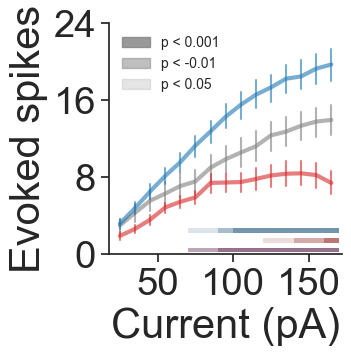

In [16]:
# overall pre, agg+, agg- comparison
fig, ax = plt.subplots(figsize=[3, 3])

palette = ["gray", "Tab:red", "Tab:blue"]
color = {"Pre": "gray", "Agg+": "tab:red", "Agg-": "tab:blue"}
combos = [
    ("Agg+", "Agg-"),
    ("Pre", "Agg+"),
    ("Pre", "Agg-"),
]

sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=palette,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
    ax=ax,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.ylim(0, 24)
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)


plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, color, base_y=1.2, y_shift=1
)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )
plt.show()

In [17]:
# estrous effect (P, E, M, D)
df_state["filename"] = df_state["filename"].str.replace(".xlsx", "").str.upper()
estrous_df = process_df_state(df_state, ["Pre"])

ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
ephys["filename"] = ephys["filename"].str.upper()
estrous_df = estrous_df[estrous_df.state == "Pre"].merge(
    ephys[ephys["Behaviour_6hFD"] == "Pre"].loc[:, ["filename", "estrous_stage", "ID_mouse", "Ih_at_-120mV"]],
    on="filename",
    how="left",
)
estrous_df.loc[estrous_df.estrous_stage == "P<E", "estrous_stage"] = "E"
estrous_df.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

In [18]:
estrous_df.groupby(['estrous_stage'])['ID_mouse'].nunique()

estrous_stage
D                   4
E                   6
M                   6
P                   3
VS to be stained    1
Name: ID_mouse, dtype: int64

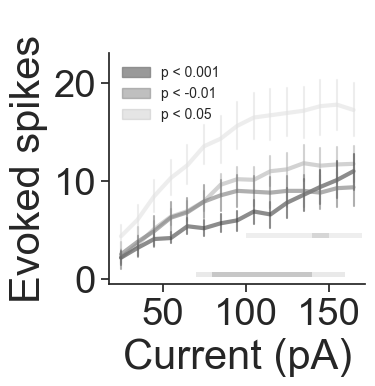

In [25]:
prop = "num_spike"
estrous_df.loc[estrous_df.filename == "S2C1 24072023", "estrous_stage"] = "E"
plot_df = estrous_df[
    (estrous_df.estrous_stage.isin(["P", "E", "M", "D"])) & (estrous_df.state == "Pre")
].dropna(subset=["estrous_stage", "Ih_at_-120mV", "Injected", prop])

estrous_combos = [
    ("P", "D"),
    ("P", "E"),
    ("P", "M"),
    ("E", "M"),
    ("E", "D"),
    ("M", "D"),
]
result_df = test_interaction_pvalues(
    plot_df,
    prop,
    estrous_combos,
    state_col="estrous_stage",
    group_var="filename",
    correction=True,
)

# generate palette for estrous stages from grays

levels = np.linspace(0.2, 0.8, 4)  # avoid 0 (black) and 1 (white)

# Use 'Greys' colormap
cmap = cm.get_cmap("Greys")

# Get colors
gray_palette = [cmap(l) for l in levels] 

palettes = {
    "P": gray_palette[-1],
    "E": gray_palette[-2],
    "M": gray_palette[-3],
    "D": gray_palette[-4],
}

fig, ax = plt.subplots(figsize=[3.3, 3])
sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="estrous_stage",
    palette=palettes,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)
# sns.stripplot(data=plot_df, x="Injected", y=prop, hue = 'estrous_stage', palette=palette, dodge=True, size=5, alpha=0.5)

ax.set_ylabel("Evoked spikes")

ax.set_xlabel("Current (pA)")
plt.ylim(-0.5, 23)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Estrous stage")
sns.despine()
plot_significance_bars_shifted(
    ax,
    plot_df,
    result_df,
    estrous_combos,
    palettes,
    state_col="estrous_stage",
    base_y=1.2,
    y_shift=1,
)
plt.title(" ", pad=10)
plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/estrous_excitability.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [29]:
result_df.to_csv(
   "test.csv",
    index=False,
)

In [20]:
variable = "num_spike"
x_variable = "Ih_at_-120mV"
formula = f'Q("{variable}") ~ Q("{x_variable}") '
plot_df['ID_mouse'] = plot_df['ID_mouse'].astype(str)

stats_df = plot_df[plot_df['Injected'] == 165].dropna(subset=['ID_mouse', 'Ih_at_-120mV'])
model = smf.mixedlm(
    formula,
    data = stats_df,
    groups=stats_df['ID_mouse']
).fit()
print(model.summary())



           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q("num_spike")
No. Observations: 50      Method:             REML          
No. Groups:       18      Scale:              83.9468       
Min. group size:  1       Log-Likelihood:     -180.1802     
Max. group size:  7       Converged:          Yes           
Mean group size:  2.8                                       
------------------------------------------------------------
                    Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept           9.338    1.878 4.973 0.000  5.658 13.019
Q("Ih_at_-120mV")   0.547    0.216 2.536 0.011  0.124  0.970
Group Var           0.000    1.284                          



In [21]:
grouped_df = plot_df.groupby("ID_mouse").agg(
    {
        "num_spike": "mean",
        "estrous_stage": "first",
        "Ih_at_-120mV": "mean",
    }
).reset_index()

In [22]:
variable = "num_spike"
x_variable = "Ih_at_-120mV"
formula = f'Q("{variable}") ~ Q("{x_variable}") '


model = smf.ols(
    formula,
    data = grouped_df,
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Q("num_spike")   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     5.990
Date:                Thu, 10 Jul 2025   Prob (F-statistic):             0.0263
Time:                        01:59:32   Log-Likelihood:                -54.808
No. Observations:                  18   AIC:                             113.6
Df Residuals:                      16   BIC:                             115.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.1276      2.29

([<matplotlib.axis.YTick at 0x32258ee90>,
 [Text(0, 0, '0'), Text(0, 12, '12'), Text(0, 24, '24'), Text(0, 36, '36')])

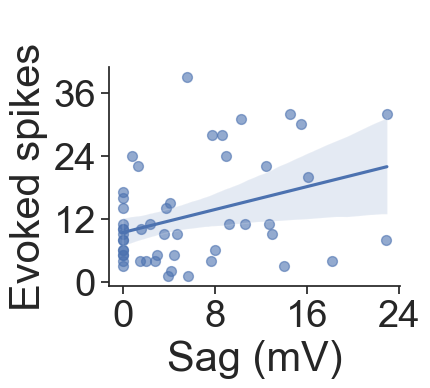

In [23]:
sns.lmplot(
    data=stats_df,
    x=x_variable,
    y=variable,
    height=4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6, "s": 50},
)
plt.xlabel("Sag (mV)")
plt.ylabel("Evoked spikes")
plt.title(" ", pad=20)
plt.xticks([0, 8,  16, 24])
plt.yticks([0,  12, 24, 36])
# plt.savefig(
#      '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/corr_sag_excitability_all.pdf',
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

([<matplotlib.axis.YTick at 0x322f4f490>,
 [Text(0, 0, '0'), Text(0, 10, '10'), Text(0, 20, '20'), Text(0, 30, '30')])

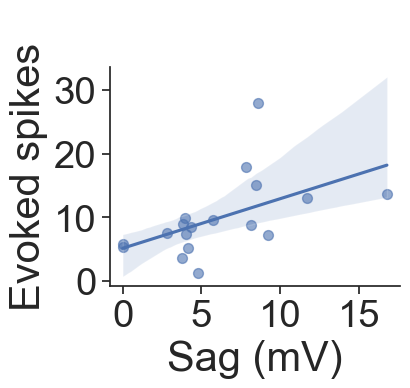

In [24]:
sns.lmplot(
    data=grouped_df,
    x=x_variable,
    y=variable,
    palette=palettes,
    height=4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6, "s": 50},
)
plt.xlabel("Sag (mV)")
plt.ylabel("Evoked spikes")
plt.title(" ", pad=20)
plt.xticks([0, 5, 10, 15])
plt.yticks([0,  10, 20, 30])
# plt.savefig(
#      '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/corr_sag_excitability.pdf',
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

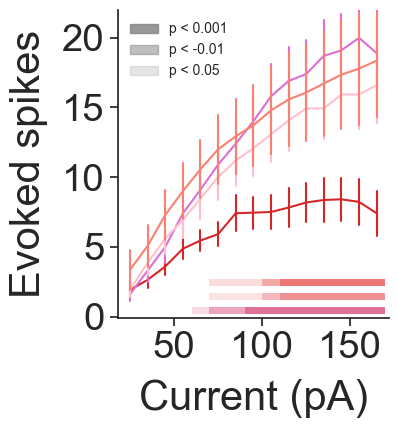

In [199]:
prop = "num_spike"

# generate random number of colors
combos = [("Agg+", "NPY Antag"), ("Agg+", "NPY1R"), ("Agg+", "NPY2R")]
result_df = test_interaction_pvalues(
    df_all, prop, combos, state_col="state", group_var="filename", correction=True
)

plot_df = df_all[df_all.state.isin(["Agg+", "NPY Antag", "NPY1R", "NPY2R"])]
fig, ax = plt.subplots(figsize=[3.5, 4])


colors = {
    "Pre": "gray",
    "Agg+": "Tab:red",
    "Agg-": "Tab:blue",
    "ZD7288": "black",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "orchid",
    "NPY1R": "pink",
    "NPY2R": "salmon",
    "NPY 10nM": "orchid",
    "NPY 100nM": "pink",
    "Ramp_Agrp_KD": "black",
}


sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=colors,
    err_style="bars",
    errorbar=("se", 1),
)


# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend_.remove()

sns.despine()
plt.xlabel("Current (pA)", labelpad=10, fontsize=30)
plt.ylabel("Evoked spikes", labelpad=10, fontsize=30)

plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, colors, state_col="state", base_y=1.2, y_shift=1
)
plt.ylim(-0.1, 22)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/{prop}_antag.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

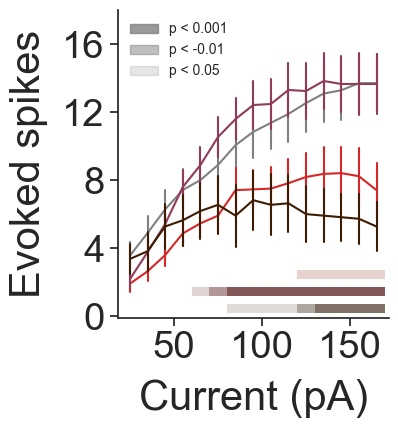

In [201]:
prop = "num_spike"

# generate random number of colors
combos = [
    ("ZD7288", "Pre"),
    ("ZD7288", "NPY-KD"),
    ("ZD7288", "Agg+"),
]


result_df = test_interaction_pvalues(
    df_all, prop, combos, state_col="state", group_var="filename", correction=True
)

plot_df = df_all[df_all.state.isin(["ZD7288", "Pre", "Agg+", "NPY-KD"])]
plot_df = plot_df[~plot_df.filename.str.contains("062025")]
fig, ax = plt.subplots(figsize=[3.5, 4])


colors = {
    "Pre": "gray",
    "Agg+": "Tab:red",
    "Agg-": "Tab:blue",
    "ZD7288": "#3D1c02",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "orchid",
    "NPY1R": "pink",
    "NPY2R": "salmon",
    "NPY 10nM": "orchid",
    "NPY 100nM": "pink",
    "Ramp_Agrp_KD": "black",
}


sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=colors,
    err_style="bars",
    errorbar=("se", 1),
)


# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend_.remove()

sns.despine()
plt.xlabel("Current (pA)", labelpad=10, fontsize=30)
plt.ylabel("Evoked spikes", labelpad=10, fontsize=30)

plt.ylim(-0.1, 18)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, colors, state_col="state", base_y=1.2, y_shift=1
)

plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Pre_Agg+_KD_ZD_pharma.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

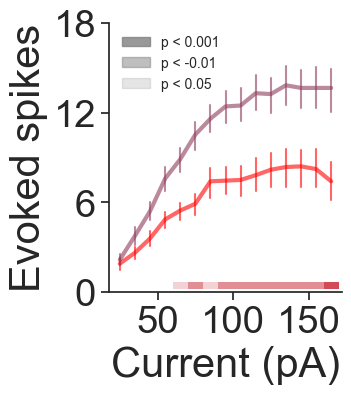

In [202]:
# only Agg+ and KD-Y

result_df = test_interaction_pvalues(
    df_all,
    prop,
    [("Agg+", "NPY-KD")],
    state_col="state",
    group_var="filename",
    correction=True,
)


sns.set(font_scale=2.5)
sns.set_style("ticks")

plot_df3 = df_all[df_all.state.isin(["Agg+", "NPY-KD"])]
fig, ax = plt.subplots(figsize=[3, 3.5])

typ = "Agg+_KD"
colors = {
    "Pre": "gray",
    "Agg+": "red",
    "ZD7288": "black",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "lightcoral",
    "NPY 10nM": "orange",
    "Agg-": "blue",
}
sns.lineplot(
    data=plot_df3,
    x="Injected",
    y=prop,
    hue="state",
    hue_order=["Agg+", "NPY-KD"],
    palette=["red", "#8F3B5A"],
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)


leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 6, 12, 18])
sns.despine(bottom=False)

plot_significance_bars_shifted(
    ax,
    plot_df3,
    result_df,
    [("Agg+", "NPY-KD")],
    colors,
    state_col="state",
    base_y=1.2,
    y_shift=1,
)

plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

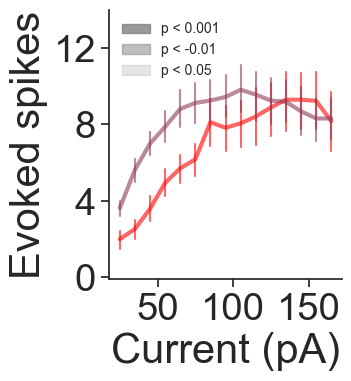

In [204]:
# only Agg+ and KD-A



sns.set(font_scale=2.5)
sns.set_style("ticks")

df_all = process_df_state(df_state, states)
plot_df3 = df_all[df_all.state.isin(["Agg+", "Ramp_Agrp_KD"])]
merged_agrpkd = pd.merge(plot_df3, ephys, on="filename", how="left")

merged_agrpkd = merged_agrpkd[merged_agrpkd.aggressive == "yes"]

result_df = test_interaction_pvalues(
    merged_agrpkd,
    prop,
    [("Agg+", "Ramp_Agrp_KD")],
    state_col="state_x",
    group_var="filename",
    correction=True,
)


fig, ax = plt.subplots(figsize=[3, 3.5])

sns.lineplot(
    data=merged_agrpkd,
    x="Injected",
    y=prop,
    hue="state_x",
    hue_order=["Agg+", "Ramp_Agrp_KD"],
    palette=["red", "#8F3B5A"],
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 4, 8, 12])
plt.ylim(-0.1, 14)
sns.despine(bottom=False)
plot_significance_bars_shifted(
    ax,
    merged_agrpkd,
    result_df,
    [("Agg+", "Ramp_Agrp_KD")],
    {"Agg+": "red", "Ramp_Agrp_KD": "#8F3B5A"},
    state_col="state_x",
    base_y=1.2,
    y_shift=1,
)

plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/agrpkd_excitability.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

# Estrous cycle influence

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       9     19   33
E                         2       4      3    9
M                         4       9     17   30
P                        10       8     18   36
P<E                       0       0      1    1
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      24      35     71  130
10.126698490606943 0.8599285347666447 16
I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         2       5      3   10
E                         3       1      0    4
P                         1       3      2    6
All                       6       9      5   20
5.1000000000000005 0.27718991430409357 4


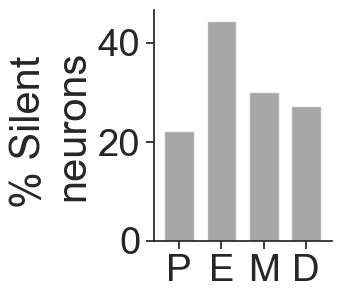

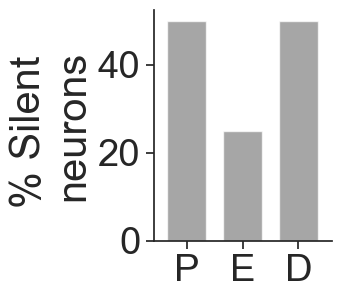

In [16]:
# silent proportion
ephys = pd.read_csv("sampled_ephys_data.csv")
ephys = ephys[ephys.experiment_day.str.contains("2025") == False]


ephys = ephys[
    ephys.I_zero_reclassified.isin(["silent", "phasic", "tonic"])
]  # was previously I_zero...
ephys.loc[(ephys["estrous_stage"] == "P to E"), "estrous_stage"] = "P"
ephys.loc[(ephys["estrous_stage"] == "D to P"), "estrous_stage"] = "D"
cols = ["silent", "phasic", "tonic"]
ephys.loc[ephys.Behaviour_6hFD.isin(["Agg+"]), "Behaviour_6hFD"] = "Post"

for state in ["Pre", "Post"]:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, "estrous_stage", "I_zero_reclassified", cols)
    silent_prop["estrous_stage"] = pd.Categorical(
        silent_prop["estrous_stage"], ["P", "E", "M", "D"]
    )
    silent_prop = silent_prop.sort_values(by=["estrous_stage"])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(["P", "E", "M", "D"])]

    silent_prop.plot(
        x="estrous_stage",
        y="silent",
        kind="bar",
        stacked=True,
        mark_right=False,
        color=["gray"],
        figsize=(2.3, 3),
        alpha=0.7,
        width=0.7,
    )

    plt.xticks(rotation=0)
    ax = plt.gca()
    plt.ylabel("% Silent \nneurons")
    plt.xlabel("")
    ax.legend_.remove()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    #     plt.title(f'{state}_silent_prop')
    # plt.savefig(f"output_figures/{state}_silent_prop.png", dpi=300, bbox_inches="tight")
    # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_{state}.pdf',
    #             dpi=300,bbox_inches='tight', transparent=True)

0.9048018533563853 0.28003767501864335


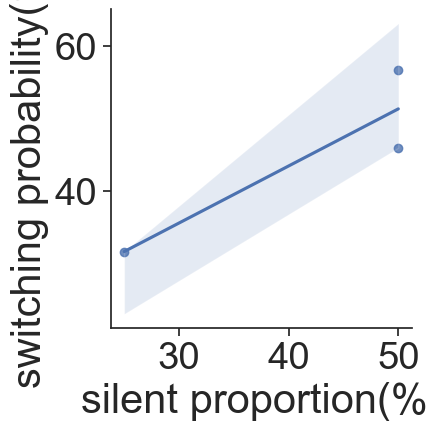

In [9]:
import scipy as sp

estrous_df = pd.read_csv(
    "../NPS_behaviour_analysis/generated_datasets/estrous_data.csv"
)
estrous_df.rename(
    columns={"Unnamed: 0": "estrous_stage", "0": "switching probability"}, inplace=True
)
corr = pd.merge(silent_prop, estrous_df, on="estrous_stage")

r, p = sp.stats.pearsonr(corr["switching probability"], corr["silent"])
print(r, p)
sns.lmplot(x="silent", y="switching probability", data=corr)
plt.xlabel("silent proportion(%)")
plt.ylabel("switching probability(%)")
plt.savefig("output_figures/silent_switching_corr.png", dpi=300, bbox_inches="tight")

1.2361923955255694 0.3215637170184157 Cm(pF)
Cm(pF) estrous_stage
P    4
E    1
M    4
D    1
Name: ID_mouse, dtype: int64
0.3008777074877423 0.8246924985915168 Firing_freq_(Hz)_I0
Firing_freq_(Hz)_I0 estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
0.29630703240274514 0.8279879866524025 Instant_freq_(Hz)
Instant_freq_(Hz) estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
1.1734621953844198 0.32370048066131973 isi_(ms)
isi_(ms) estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
1.7043416753342682 0.1715924273639941 CaT
CaT estrous_stage
P    11
E     4
M    11
D     9
Name: ID_mouse, dtype: int64
3.995176486095409 0.01005280333215112 Ih_at_-120mV
Ih_at_-120mV estrous_stage
P    11
E     4
M    11
D     9
Name: ID_mouse, dtype: int64
estrous_stage
P    36
E     9
M    30
D    33
Name: experiment_day, dtype: int64
Ih_at_-120mV 0.01005280333215112
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 m

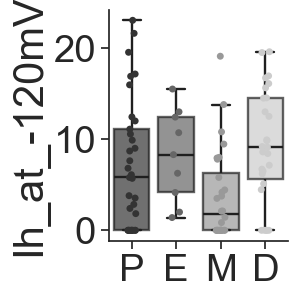

1.476400923100761 0.2290133893861384 AP_ampl
AP_ampl estrous_stage
P    11
E     3
M     9
D     9
Name: ID_mouse, dtype: int64
1.5881805278333008 0.20107132024829077 AP_halfwidth
AP_halfwidth estrous_stage
P    11
E     3
M     9
D     9
Name: ID_mouse, dtype: int64
1.6310202393090492 0.19076444624808533 AP_time_to_peak
AP_time_to_peak estrous_stage
P    11
E     3
M     9
D     9
Name: ID_mouse, dtype: int64
0.5933999102473689 0.6208548755069654 area(mV_ms)
area(mV_ms) estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
0.3135820970868044 0.8154928679321201 rheobase_at_-60mV_(pA)
rheobase_at_-60mV_(pA) estrous_stage
P     7
E     4
M    10
D     6
Name: ID_mouse, dtype: int64
0.2092928321715171 0.8897387776680089 AHP_(mV)
AHP_(mV) estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
0.2686332376353 0.8478742757963978 Vm
Vm estrous_stage
P    12
E     4
M    11
D    10
Name: ID_mouse, dtype: int64
1.3043707951222063 0.2777274908682667 Input

In [14]:
# IH current
ls = [
    "Cm(pF)",
    "Firing_freq_(Hz)_I0",
    "Instant_freq_(Hz)",
    "isi_(ms)",
    "CaT",
    "Ih_at_-120mV",
    "AP_ampl",
    "AP_halfwidth",
    "AP_time_to_peak",
    "area(mV_ms)",
    "rheobase_at_-60mV_(pA)",
    "AHP_(mV)",
    "Vm",
    "Input_Resistance",
    "sPSC_frequency",
    "sPSC_Amplitude(pA)",
    "sPSCs_Rise time",
    "sPSCs (decay)",
    "AC-I0",
    "AC_-60",
]

sns.set(font_scale=2.5)
sns.set_style("ticks")

for state in ["Pre"]:  # change Pre/Post accordingly!
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df["estrous_stage"] = pd.Categorical(
            state_df["estrous_stage"], ["P", "E", "M", "D"]
        )
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        if "AP" in column:
            state_df = state_df[state_df[column] > 0]  # filter out APs with 0 amplitude

        try:

            stat, p = stats.f_oneway(
                state_df[column][state_df["estrous_stage"] == "P"].dropna(),
                state_df[column][state_df["estrous_stage"] == "E"].dropna(),
                state_df[column][state_df["estrous_stage"] == "M"].dropna(),
                state_df[column][state_df["estrous_stage"] == "D"].dropna(),
            )
            print(stat, p, column)

            print(column,  state_df.dropna(subset=[column]).groupby('estrous_stage').ID_mouse.nunique())

            if p < 0.05:
                print(state_df.groupby('estrous_stage')['experiment_day'].nunique())
                print(column, p)
                state_df = state_df.loc[:, ["estrous_stage", column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(
                    endog=state_df[column], groups=state_df["estrous_stage"], alpha=0.05
                )
                print(multiple_comp_result.summary())

                fig, ax = plt.subplots(figsize=(2.3, 3))

                sns.stripplot(
                    x="estrous_stage",
                    y=column,
                    data=state_df,
                    palette="gray",
                    order=["P", "E", "M", "D"],
                )
                sns.boxplot(
                    x="estrous_stage",
                    y=column,
                    data=state_df,
                    boxprops=dict(alpha=0.7),
                    order=["P", "E", "M", "D"],
                    saturation=8,
                    linewidth=1.7,
                    showfliers=False,
                    palette="gray",
                )
                sns.despine()
                # plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel("")

                # plt.title(f'{state}_{column}', pad = 20)
                # plt.savefig(
                #     f"output_figures/{state}_{column}.png", dpi=300, bbox_inches="tight"
                # )

            plt.show()
        except Exception:
            print(column)
            continue

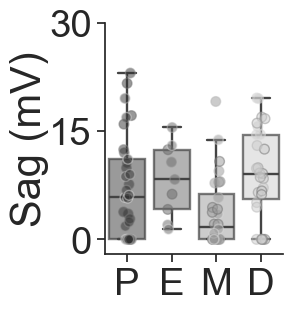

In [11]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Ih_at_-120mV",
    data=state_df,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["#707070", "#939393", "#B7B7B7", "#DBDBDB"],
    boxprops=dict(alpha=0.7),
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Ih_at_-120mV",
    data=state_df,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor=["#707070", "#939393", "#B7B7B7", "#DBDBDB"],
    palette="gray",
    alpha=0.5,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

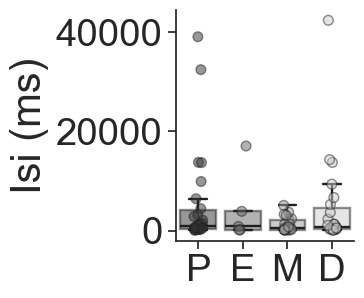

In [12]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")
param = "isi_(ms)"

non_silent = state_df[state_df.I_zero_reclassified != "silent"]
# non_silent = state_df
ax = sns.boxplot(
    x="estrous_stage",
    y=param,
    data=non_silent,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="estrous_stage",
    y=param,
    data=non_silent,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
)
ax.set_xlabel("")
ax.set_ylabel("Isi (ms)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))


sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{param}_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [79]:
group_counts = state_df["estrous_stage"].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby("estrous_stage")["ID_mouse"].nunique()
print(f"Mouse numbers: \n{unique_counts}")

Cell numbers: 
estrous_stage
D    47
M    40
P    39
E    22
Name: count, dtype: int64
Mouse numbers: 
estrous_stage
P    10
E     3
M     8
D     5
Name: ID_mouse, dtype: int64


IH                no  yes  All
estrous_stage                 
?                  0    4    4
D                  5   22   27
E                  0    9    9
M                 12   16   28
P                 10   23   33
P<E                0    1    1
VS to be stained   1    0    1
not taken          2    2    4
All               30   77  107
13.321834090232358 0.0646445480807496 7
estrous_stage
?                    1
D                   10
E                    4
M                   11
P                   12
P<E                  1
VS to be stained     1
no VS                1
not taken            1
Name: ID_mouse, dtype: int64
IH estrous_stage         no         yes
4              P  30.303030   69.696970
2              E   0.000000  100.000000
3              M  42.857143   57.142857
1              D  18.518519   81.481481


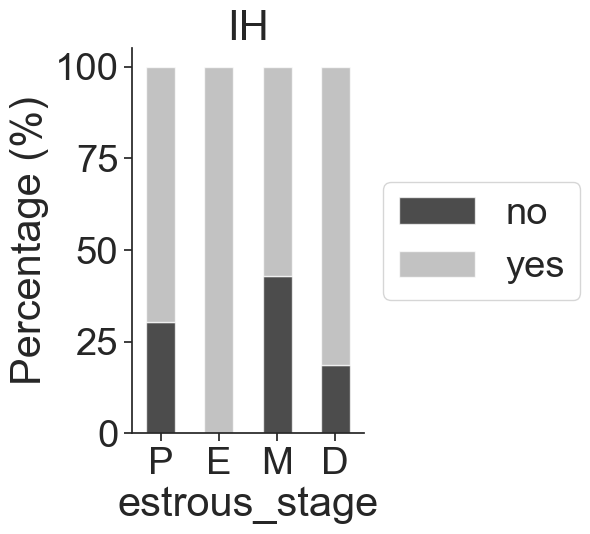

0.9970849412303634 0.0029150587696364916
                            OLS Regression Results                            
Dep. Variable:                     no   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     8.833
Date:                Thu, 10 Jul 2025   Prob (F-statistic):            0.00328
Time:                        22:28:29   Log-Likelihood:                -938.07
No. Observations:                 228   AIC:                             1880.
Df Residuals:                     226   BIC:                             1887.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

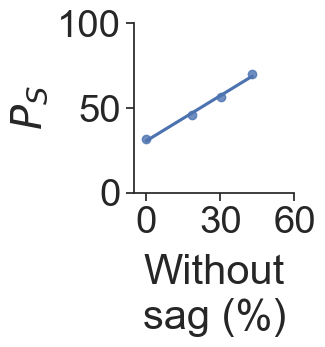

In [17]:
import scipy as sp

cols = ["no", "yes"]
ephys.loc[(ephys["Ih_at_-120mV"] == 0), "IH"] = "no"
ephys.loc[(ephys["Ih_at_-120mV"] > 0), "IH"] = "yes"


estrous_df = pd.read_csv(
    "../NPS_behaviour_analysis/generated_datasets/estrous_data.csv"
)
estrous_df.rename(
    columns={"Unnamed: 0": "estrous_stage", "0": "switching probability"}, inplace=True
)
ephys_pre = ephys[ephys.Behaviour_6hFD == "Pre"]


raw = pd.read_csv(
    "../NPS_behaviour_analysis/negative_parental_switch_summary.csv", encoding="cp1252"
)
raw = raw[
    (raw["estrous_stage"].isin(["P", "E", "M", "D"]))
    & (raw["exp_cond"].isin(["all_stressor_5h", "food_deprivation"]))
]
raw = raw.loc[:, ["estrous_stage", "state_after"]]
raw["state_after"] = raw["state_after"].apply(lambda x: 1 if x == "Agg+" else 0)


for column in ["IH"]:  # cat_categ', 'IH', 'Adaptive'
    esprop = proportion(ephys_pre, "estrous_stage", column, cols)
    print(ephys_pre.groupby("estrous_stage")["ID_mouse"].nunique())
    esprop["estrous_stage"] = pd.Categorical(
        esprop["estrous_stage"], ["P", "E", "M", "D"]
    )
    esprop = esprop.sort_values(by=["estrous_stage"]).dropna()
    prop_plot(esprop, "estrous_stage")
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on="estrous_stage")
    r, p = sp.stats.pearsonr(corr["switching probability"], corr["no"])
    print(r, p)

    stats_df = raw.merge(esprop, on="estrous_stage")
    response_var = "state_after"
    formula = f'no ~ Q("{response_var}")'
    model = smf.ols(formula, data=stats_df).fit()
    print(model.summary())

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    sns.lmplot(
        x="no", y="switching probability", data=corr, ci=None, height=3.5, aspect=1
    )  # plt.xlabel(r'$\mathit{P}_{\mathit{S}}$')
    plt.ylim([0, 100])
    plt.xlim([-5, 60])
    plt.xticks([0, 30, 60])
    plt.xlabel("Without\nsag (%)", labelpad=10)  # plt.xlabel(f'% {column}')
    plt.ylabel(r"$\mathit{P}_{\mathit{S}}$")  # plt.ylabel('Switching probability(%)')
    #     plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{column}_switching_corr.pdf',
    #             dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

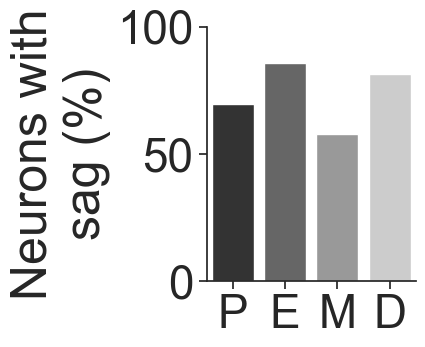

In [81]:
# Plot % of neurons that have Ih per estrous state
sns.set(rc={"figure.figsize": (2.7, 3.3)})
sns.set(font_scale=3)
sns.set_style("ticks")
sns.barplot(x="estrous_stage", y="yes", data=esprop, palette="gray")
plt.xlabel("")
plt.ylabel("Neurons with\nsag (%)")
plt.ylim(0, 100)
sns.despine(bottom=False)
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/percent_sag_estrous.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [276]:
from scipy.optimize import curve_fit


def func(x, a, b, c):
    return a * np.exp(-b * x) + c

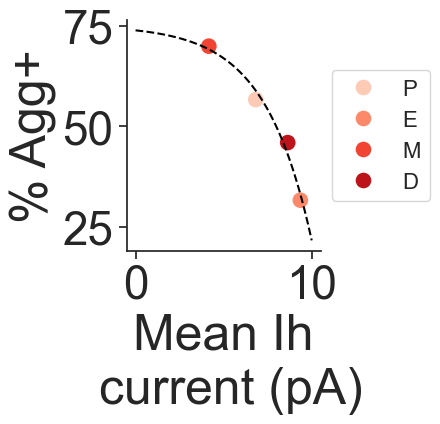

In [277]:
# mean of IH with estrous stage
mean_ih = ephys_pre.groupby("estrous_stage")["Ih_at_-120mV"].mean().reset_index()
grouped_df = pd.merge(mean_ih, estrous_df, on="estrous_stage")

x = grouped_df["Ih_at_-120mV"]
y = grouped_df["switching probability"] * 100
popt, pcov = curve_fit(func, x, y)

plot_x = np.linspace(0, 10, 100)
plot_y = func(plot_x, *popt) / 100


plt.subplots(figsize=(2.5, 3))
plt.plot(plot_x, plot_y, color="black", linestyle="--")
sns.despine()


sns.scatterplot(
    x="Ih_at_-120mV",
    y="switching probability",
    hue="estrous_stage",
    data=grouped_df,
    hue_order=["P", "E", "M", "D"],
    palette="Reds",
    alpha=1,
    s=150,
)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=16)
plt.xlabel("Mean Ih\n current (pA)")
plt.ylabel("% Agg+")
plt.show()

In [278]:
residuals = y - func(x, *popt)
ss_res = np.sum(residuals**2)

ss_tot = np.sum((y - np.mean(y)) ** 2)


r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.9793312681128283


### Corr btw Sag amplitude and %Agg+

In [279]:
from scipy.optimize import curve_fit


def func(x, a, b, c):
    return a * np.exp(-b * x) + c

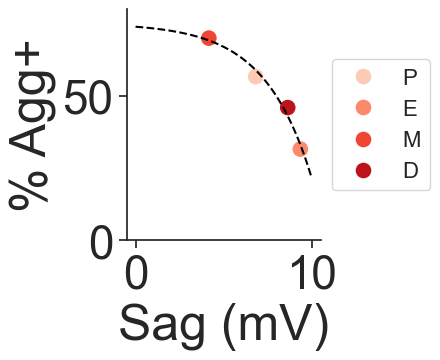

In [280]:
# mean of IH with estrous stage
mean_ih = ephys_pre.groupby("estrous_stage")["Ih_at_-120mV"].mean().reset_index()
grouped_df = pd.merge(mean_ih, estrous_df, on="estrous_stage")

x = grouped_df["Ih_at_-120mV"]
y = grouped_df["switching probability"] * 100
popt, pcov = curve_fit(func, x, y)

plot_x = np.linspace(0, 10, 100)
plot_y = func(plot_x, *popt) / 100


plt.subplots(figsize=(2.5, 3))
plt.plot(plot_x, plot_y, color="black", linestyle="--")

sns.scatterplot(
    x="Ih_at_-120mV",
    y="switching probability",
    hue="estrous_stage",
    data=grouped_df,
    hue_order=["P", "E", "M", "D"],
    palette="Reds",
    alpha=1,
    s=150,
)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=16)
plt.xlabel("Sag (mV)")
plt.ylabel("% Agg+")
plt.ylim(0, 80)
# plt.xlim(0,10)
sns.despine()
plt.show()

## Individual plots

### Pre

In [204]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys["Behaviour_6hFD"] == "Pre"]

In [213]:
print(
    f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice"
)

Number of P neurons: 33 from 10 mice
Number of E neurons: 16 from 3 mice
Number of M neurons: 33 from 8 mice
Number of D neurons: 40 from 5 mice


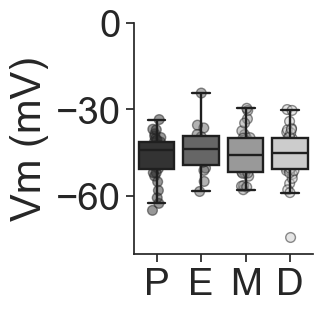

In [214]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Vm",
    data=ephys_estrous,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Vm",
    data=ephys_estrous,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

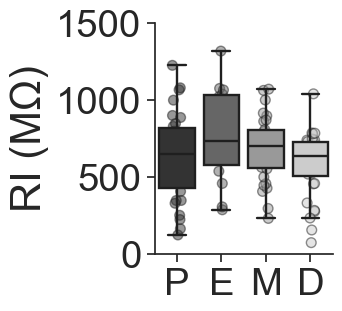

In [215]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Input_Resistance",
    data=ephys_estrous,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Input_Resistance",
    data=ephys_estrous,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

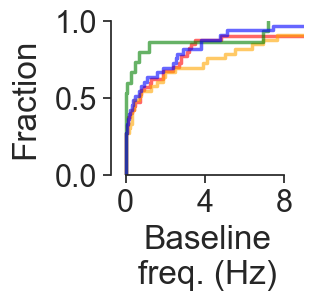

In [211]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {"P": "blue", "E": "green", "M": "orange", "D": "red"}
valid_estrous_stages = ["P", "E", "M", "D"]
ephys_estrous2 = ephys_estrous[
    ephys_estrous["estrous_stage"].isin(valid_estrous_stages)
]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_estrous2,
    x="Firing_freq_(Hz)_I0",
    hue="estrous_stage",
    linewidth=2.5,
    legend=False,
    stat="proportion",
    palette=custom_palette,
    alpha=0.6,
    hue_order=["P", "E", "M", "D"],
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [216]:
estrous_counts = ephys_estrous2["estrous_stage"].value_counts()
estrous_counts

estrous_stage
D    40
P    33
M    33
E    16
Name: count, dtype: int64

In [218]:
# stats - one-way ANOVA
ephys_estrous2.rename(columns={"Firing_freq_(Hz)_I0": "firing_freq"}, inplace=True)

model = smf.ols("firing_freq ~ estrous_stage", data=ephys_estrous2).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

# groups = ephys_estrous2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
# groups = [group for group in groups if len(group) > 0]
# anova_result = f_oneway(*groups)
# print("One-way ANOVA p-value:", anova_result.pvalue)

                    sum_sq     df         F   PR(>F)
estrous_stage    22.196841    3.0  0.782361  0.50609
Residual       1106.492320  117.0       NaN      NaN


### Post (Agg+/- pooled)

In [219]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv("sampled_ephys_data.csv")
ephys_post = ephys[
    (ephys["Behaviour_6hFD"] == "Agg+") | (ephys["Behaviour_6hFD"] == "Agg-")
]

In [220]:
print(
    f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice"
)

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 10 from 1 mice
Number of D neurons: 8 from 2 mice


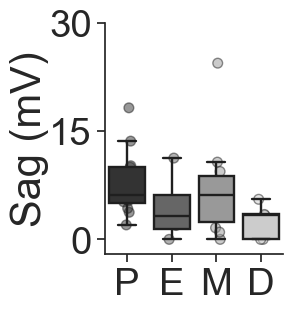

In [ ]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Ih_at_-120mV",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Ih_at_-120mV",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
    zorder=1,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

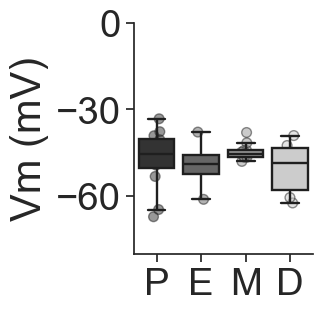

In [ ]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Vm",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Vm",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

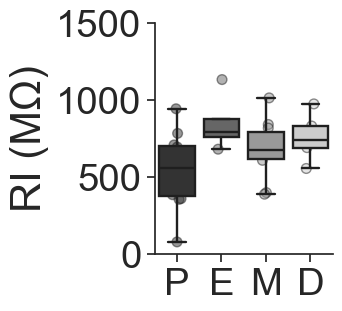

In [ ]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="Input_Resistance",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
)
ax = sns.stripplot(
    x="estrous_stage",
    y="Input_Resistance",
    data=ephys_post,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

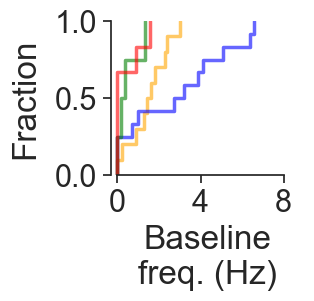

In [225]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC.
# - IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {"P": "blue", "E": "green", "M": "orange", "D": "red"}
valid_estrous_stages = ["P", "E", "M", "D"]
ephys_post2 = ephys_post[ephys_post["estrous_stage"].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_post2,
    x="Firing_freq_(Hz)_I0",
    hue="estrous_stage",
    linewidth=2.5,
    legend=False,
    stat="proportion",
    palette=custom_palette,
    alpha=0.6,
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_post2.groupby("estrous_stage")["Firing_freq_(Hz)_I0"].apply(
    lambda x: x.dropna().tolist()
)
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD
ephys_post3 = ephys_post2.dropna(subset=["Firing_freq_(Hz)_I0", "estrous_stage"])
tukey_results = pairwise_tukeyhsd(
    ephys_post3["Firing_freq_(Hz)_I0"], ephys_post3["estrous_stage"]
)
print(tukey_results)

One-way ANOVA p-value: 0.02302615717756743
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     D      E   0.0408    1.0  -2.908 2.9896  False
     D      M   1.0803  0.601 -1.2787 3.4394  False
     D      P   2.3917 0.0375  0.1075 4.6758   True
     E      M   1.0395 0.7218 -1.6631 3.7421  False
     E      P   2.3508 0.0937 -0.2867 4.9883  False
     M      P   1.3113 0.2808 -0.6447 3.2674  False
---------------------------------------------------


# NPY administration

In [199]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv("sampled_ephys_data.csv")
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')

In [200]:
print(
    f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice"
)

Number of Pre neurons: 128 from 24 mice
Number of NPY neurons: 11 from 4 mice


In [201]:
# ephys_npy

In [202]:
ephys_npy.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'aggressive',
       'Cm(pF)', 'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'estrous_confirmation'],
      dtype='object')

In [203]:
ephys_npy.dropna(subset=["Input_Resistance"]).groupby("Behaviour_6hFD")["experiment_day"].nunique()

Behaviour_6hFD
Agg+               19
Agg-               22
Pre               103
ZD7288              9
ZD7288_20           3
agrp_100           15
agrpkd             39
npy1r_antag        15
npy2r_antag        14
npy_10             10
npy_100            11
npy_100_paired      3
npy_10_paired       6
npy_antag          14
npykd              19
Name: experiment_day, dtype: int64

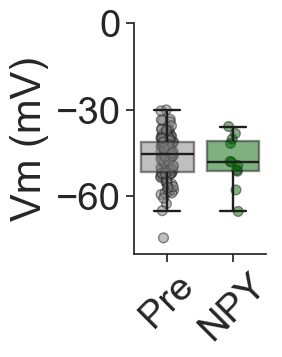

In [204]:
# Membrane voltage / RMP + NPY
ephys_npy.dropna(subset=["Vm"]).groupby("Behaviour_6hFD")["Vm"].describe()
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

MannwhitneyuResult(statistic=806.0, pvalue=0.02008964331145264)


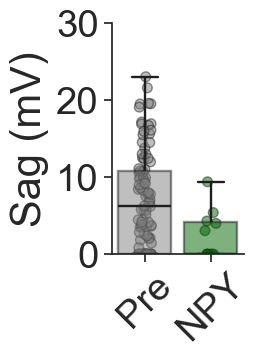

In [264]:
# Ih + NPY

print(mannwhitneyu(
    ephys_npy[ephys_npy.Behaviour_6hFD == "Pre"]["Ih_at_-120mV"].dropna(),
    ephys_npy[ephys_npy.Behaviour_6hFD == "npy_100"]["Ih_at_-120mV"].dropna(),
    alternative="two-sided",

))

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

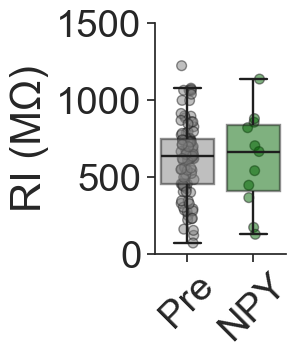

In [206]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [207]:
ephys_npy.groupby("Behaviour_6hFD")["ID_mouse"].nunique()

Behaviour_6hFD
Agg+               6
Agg-               3
Pre               24
ZD7288             1
ZD7288_20          1
agrp_100           5
agrpkd             7
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     1
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64

In [208]:
# Proportion of silent neurons
cols = ["silent", "phasic", "tonic"]
cat = ["Pre", "npy_100"]
silent_npy = proportion(
    ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "I_zero", cols
)
silent_npy["Behaviour_6hFD"] = pd.Categorical(silent_npy["Behaviour_6hFD"], cat)
silent_npy = silent_npy.sort_values(by=["Behaviour_6hFD"])

I_zero          phasic  phasic   silent  tonic  tonic   All
Behaviour_6hFD                                             
Pre                 22        1      33     68       2  126
npy_100              2        0       7      2       0   11
All                 24        1      40     70       2  137
7.659239503882361 0.10488906473430448 4


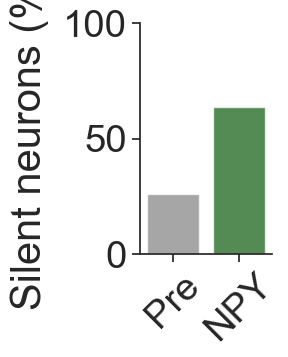

In [209]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_npy,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "npy_100"],
    palette=npy,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "NPY"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0, 100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
# plt.savefig(
#     # "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [210]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[
    (ephys_npy["Behaviour_6hFD"] == "Pre") | (ephys_npy["Behaviour_6hFD"] == "npy_100")
]

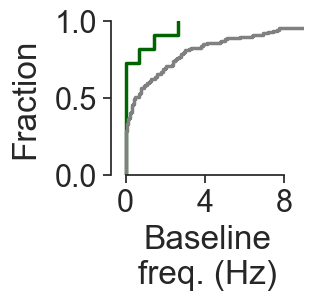

In [211]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_npy_ff,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=npy,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [212]:
# stats U test
pre_ff = ephys_npy_ff[ephys_npy_ff["Behaviour_6hFD"] == "Pre"][
    "Firing_freq_(Hz)_I0"
].dropna()
npy_ff = ephys_npy_ff[ephys_npy_ff["Behaviour_6hFD"] == "npy_100"][
    "Firing_freq_(Hz)_I0"
].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, npy_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.0155826958267656


# AgRP administration

In [231]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv("sampled_ephys_data.csv")
ephys_agrp = ephys.copy()
ephys_agrp["Behaviour_6hFD"] = ephys_agrp["Behaviour_6hFD"].replace(
    ["agrp_100_paired", "agrp_100"], "agrp"
)

In [232]:
# ephys_agrp.Behaviour_6hFD.unique()
# WE EXPECT 15 neurons from 5 mice

In [233]:
print(
    f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice"
)
print(
    f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice"
)

Number of Pre neurons: 128 from 24 mice
Number of AgRP neurons: 15 from 5 mice


In [234]:
ephys_agrp.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'aggressive',
       'Cm(pF)', 'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'estrous_confirmation'],
      dtype='object')

In [235]:
param = "sPSCs_Rise time"
selected = ephys_agrp[ephys_agrp[param]!=0].dropna(subset=[param])
selected.groupby("Behaviour_6hFD")["ID_mouse"].nunique()

Behaviour_6hFD
Agg+            6
Agg-            3
Pre            18
ZD7288          1
ZD7288_20       1
agrp            2
agrpkd          7
npy1r_antag     2
npy2r_antag     3
npy_10          3
npy_100         4
npy_antag       3
npykd           3
Name: ID_mouse, dtype: int64

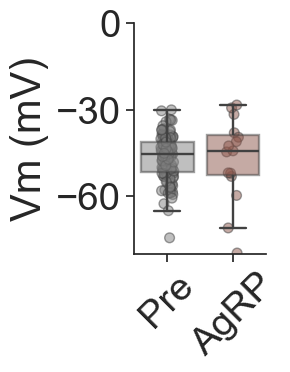

In [236]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

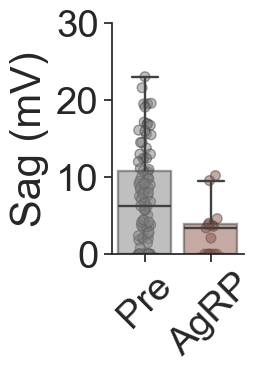

In [237]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

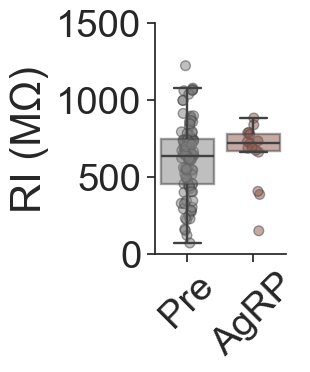

In [238]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [239]:
# stats U test
from scipy.stats import mannwhitneyu

pre_ri = ephys_agrp[ephys_agrp["Behaviour_6hFD"] == "Pre"]["Input_Resistance"].dropna()
agrp_ri = ephys_agrp[ephys_agrp["Behaviour_6hFD"] == "agrp"][
    "Input_Resistance"
].dropna()
u_statistic, p_value = mannwhitneyu(pre_ri, agrp_ri)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.25465033265965276


In [240]:
# Proportion of silent neurons
cols = ["silent", "phasic", "tonic"]
cat = ["Pre", "agrp"]
silent_agrp = proportion(
    ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "I_zero", cols
)
silent_agrp["Behaviour_6hFD"] = pd.Categorical(silent_agrp["Behaviour_6hFD"], cat)
silent_agrp = silent_agrp.sort_values(by=["Behaviour_6hFD"])

I_zero          phasic  phasic   silent  tonic  tonic   All
Behaviour_6hFD                                             
Pre                 22        1      33     68       2  126
agrp                 2        0       5      8       0   15
All                 24        1      38     76       2  141
0.7460317460317459 0.9455332873049301 4


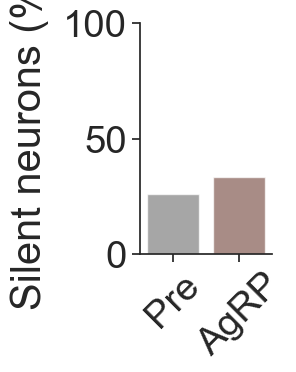

In [241]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_agrp,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "agrp"],
    palette=agrp,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "AgRP"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0, 100)
sns.despine()
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [242]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[
    (ephys_agrp["Behaviour_6hFD"] == "Pre") | (ephys_agrp["Behaviour_6hFD"] == "agrp")
]

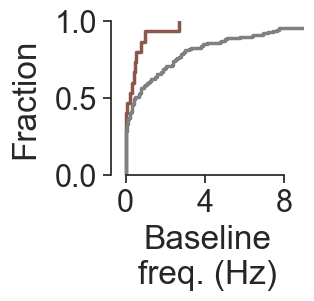

In [243]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_agrp_ff,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=agrp,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [244]:
# stats U test
pre_ff = ephys_agrp_ff[ephys_agrp_ff["Behaviour_6hFD"] == "Pre"][
    "Firing_freq_(Hz)_I0"
].dropna()
agrp_ff = ephys_agrp_ff[ephys_agrp_ff["Behaviour_6hFD"] == "agrp"][
    "Firing_freq_(Hz)_I0"
].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, agrp_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.06023620755321908


In [245]:
ephys_agrp.Behaviour_6hFD.value_counts()

Behaviour_6hFD
Pre               128
agrpkd             48
Agg+               22
Agg-               22
npykd              19
npy_antag          17
npy1r_antag        15
npy2r_antag        15
agrp               15
npy_100            11
npy_10             10
ZD7288              9
npy_10_paired       6
ZD7288_20           5
npy_100_paired      4
Name: count, dtype: int64

MannwhitneyuResult(statistic=318.0, pvalue=0.7289281824361975)
Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      20
agrpkd    30
Name: experiment_day, dtype: int64


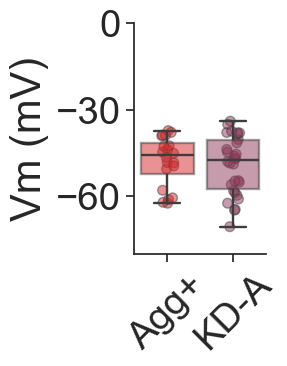

In [263]:
agrpkd_selected = ephys_agrp[
    (ephys_agrp["Behaviour_6hFD"].isin(["Agg+", "agrpkd"]))
    & (ephys_agrp.aggressive == "yes")
]

print(stats.mannwhitneyu(
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"]["Vm"].dropna(),
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"]["Vm"].dropna(),
    alternative="two-sided",
))


print(agrpkd_selected.dropna(subset='Vm').groupby("Behaviour_6hFD")['ID_mouse'].nunique())
print(agrpkd_selected.dropna(subset='Vm').groupby("Behaviour_6hFD")['experiment_day'].nunique())

# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

MannwhitneyuResult(statistic=171.0, pvalue=0.08105349944453671)
Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      19
agrpkd    26
Name: experiment_day, dtype: int64


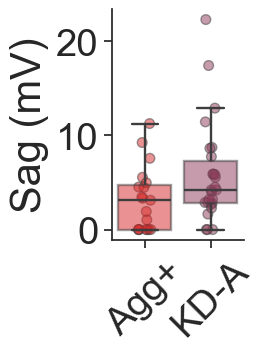

In [250]:
print(stats.mannwhitneyu(
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"]["Ih_at_-120mV"].dropna(),
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"]["Ih_at_-120mV"].dropna(),
))
print(agrpkd_selected.dropna(subset='Ih_at_-120mV').groupby("Behaviour_6hFD")['ID_mouse'].nunique())
print(agrpkd_selected.dropna(subset='Ih_at_-120mV').groupby("Behaviour_6hFD")['experiment_day'].nunique())


ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(-2, 22)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

MannwhitneyuResult(statistic=160.0, pvalue=0.046838040421928066)
Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      19
agrpkd    26
Name: experiment_day, dtype: int64


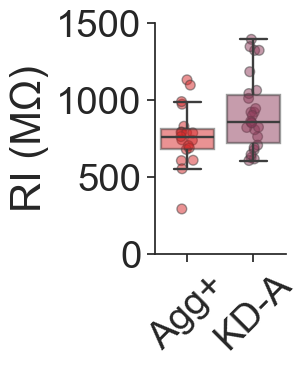

In [252]:
print(stats.mannwhitneyu(
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"]["Input_Resistance"].dropna(),
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"]["Input_Resistance"].dropna(),

))

print(agrpkd_selected.dropna(subset='Input_Resistance').groupby("Behaviour_6hFD")['ID_mouse'].nunique())
print(agrpkd_selected.dropna(subset='Input_Resistance').groupby("Behaviour_6hFD")['experiment_day'].nunique())


ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 6       9      5   20
agrpkd               5      11     15   31
All                 11      20     20   51
3.06074780058651 0.21645471970060903 2


Text(0.5, 1.0, ' ')

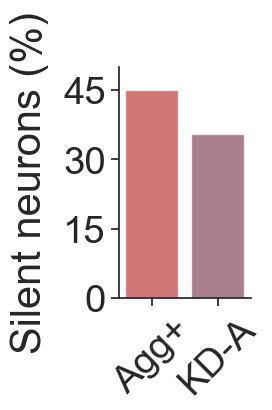

In [260]:
# Proportion of silent neurons
cols = ["silent", "phasic", "tonic"]
cat = ["Agg+", "agrpkd"]
silent_agrp = proportion(
    agrpkd_selected[agrpkd_selected.Behaviour_6hFD.isin(cat)],
    "Behaviour_6hFD",
    "I_zero",
    cols,
)
silent_agrp["Behaviour_6hFD"] = pd.Categorical(silent_agrp["Behaviour_6hFD"], cat)
silent_agrp = silent_agrp.sort_values(by=["Behaviour_6hFD"])


plt.subplots(figsize=(1.7, 3))
g = sns.barplot(
    silent_agrp,
    x="Behaviour_6hFD",
    y="silent",
    order=["Agg+", "agrpkd"],
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Agg+", "KD-A"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 15))
plt.ylim(0, 50)
sns.despine()
plt.title(" ", pad=20)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      20
agrpkd    30
Name: experiment_day, dtype: int64


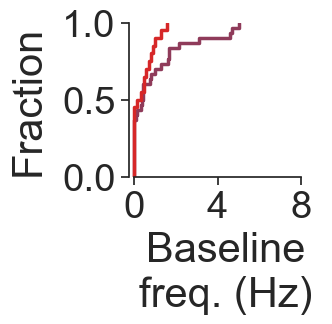

In [261]:
print(agrpkd_selected.dropna(subset='Firing_freq_(Hz)_I0').groupby("Behaviour_6hFD")['ID_mouse'].nunique())
print(agrpkd_selected.dropna(subset='Firing_freq_(Hz)_I0').groupby("Behaviour_6hFD")['experiment_day'].nunique())

plt.subplots(figsize=(2.5, 2.0))
cum = sns.ecdfplot(
    data=agrpkd_selected,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    hue_order=["Agg+", "agrpkd"],
    palette=["Tab:red", "#8F3B5A"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [262]:
# stats U test
pre_ff = agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"][
    "Firing_freq_(Hz)_I0"
].dropna()
agrp_ff = agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"][
    "Firing_freq_(Hz)_I0"
].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, agrp_ff)
print("Mann-Whitney U test p-value:",u_statistic, p_value)

Mann-Whitney U test p-value: 252.5 0.3360430843343568


In [150]:
agrpkd_selected.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'aggressive',
       'Cm(pF)', 'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'estrous_confirmation'],
      dtype='object')

MannwhitneyuResult(statistic=277.5, pvalue=0.6524996199679536)
Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      22
agrpkd    32
Name: experiment_day, dtype: int64


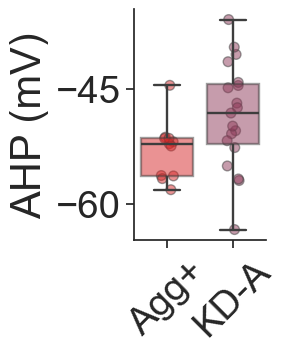

In [154]:
print(stats.mannwhitneyu(
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"]["AHP_(mV)"].dropna(),
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"]["AHP_(mV)"].dropna(),
))


ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=agrpkd_selected[agrpkd_selected["AHP_(mV)"] != 0],
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=agrpkd_selected[agrpkd_selected["AHP_(mV)"] != 0],
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("AHP (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ahp_agrpkd.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [94]:
agrpkd_selected.columns

Index(['Unnamed: 0', 'experiment_day', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'aggressive',
       'Cm(pF)', 'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'estrous_confirmation'],
      dtype='object')

MannwhitneyuResult(statistic=399.0, pvalue=0.002701421550132973)
Behaviour_6hFD
Agg+      6
agrpkd    4
Name: ID_mouse, dtype: int64
Behaviour_6hFD
Agg+      21
agrpkd    25
Name: experiment_day, dtype: int64


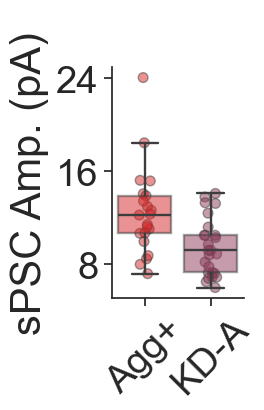

In [159]:
print(stats.mannwhitneyu(
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "Agg+"]["sPSC_Amplitude(pA)"].dropna(),
    agrpkd_selected[agrpkd_selected["Behaviour_6hFD"] == "agrpkd"]["sPSC_Amplitude(pA)"].dropna(),
))
print(agrpkd_selected.dropna(subset='sPSC_Amplitude(pA)').groupby("Behaviour_6hFD")['ID_mouse'].nunique())
print(agrpkd_selected.dropna(subset='sPSC_Amplitude(pA)').groupby("Behaviour_6hFD")['experiment_day'].nunique())

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC Amp. (pA)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)
plt.title(" ", pad=20)

plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/spsc_smplitude_agrpkd.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)